# Part 1 — reconstruction: joint BCE training vs. reconstruction-only baseline

Compares the **Masserstein reconstruction loss** for one fixed architecture
(`conv1d-ae-32-16-8-latent-10`, Δm/z = 0.55) between two campaigns:

- `kidney-architecture-binning`, `grid_0010` — reconstruction-only (single-objective,
  10 epochs). Selected this architecture/binning as the campaign winner (see
  `13_08_26_architecture_and_binning/report_binning/methodology.md`).
- `kidney-architecture-predictive`, `grid_0000` — joint reconstruction + molecule
  classification (`balanced_bce` head, 15 epochs, `../report/methodology.md` §5).

Scope for this pass: **`grid_0000` (plain balanced BCE) only** — the other six
predictive ablations (contractive/contrastive/nnPU) are deferred to a later part once
this baseline comparison is reviewed. Both experiments' `MassersteinLoss` are the exact
same criterion (verified against both campaigns' `config.json`), so their logged
`masserstein`/`validation_masserstein` values are directly comparable — no need to
re-run inference here.


In [1]:
import os
from pathlib import Path

import pandas as pd

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import read_campaign, read_entropy_campaign
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-27 02:44:50,666 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 02:44:50,668 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


## Config

`BASELINE_*` selects the reconstruction-only campaign's task by architecture name and
binning step rather than a hardcoded `grid_id` — grid indices are an implementation
detail of one YAML's ordering, architecture name and binning step are not.


In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE_DIRECTORY = WORKSPACE / "models" / MODEL_CONTEXT

BASELINE_EXPERIMENT_NAME = "kidney-architecture-binning"
BASELINE_ARCHITECTURE = "conv1d-ae-32-16-8-latent-10"
BASELINE_BINNING_STEP = 0.55

PREDICTIVE_EXPERIMENT_NAME = "kidney-architecture-predictive"
PREDICTIVE_ENTROPY_STATUS_DIRECTORY = (
    Path.home() / "entropy-runs" / PREDICTIVE_EXPERIMENT_NAME / "predictive-20260824-04" / "plan" / "status"
)
PREDICTIVE_OBJECTIVE_LABEL = "balanced_bce"  # grid_0000 — see part_0's describe_objective

theme = resolve_theme(None)
theme.apply()


## Load both campaigns

`read_campaign` now resolves the `__cfg_<fingerprint>`-namespaced directory that
`kidney-architecture-binning` actually materializes on disk (fixed in
`analysis.autoencoder.experiments.campaign_reader` — it previously only looked for the
plain, un-namespaced `experiment_name` directory and silently could not find this or
any other campaign materialized after the CLI's namespacing change). `read_entropy_campaign`
reads the predictive campaign's SLURM orchestration mirror the same way `part_0` does,
now as a reusable library function instead of one-off notebook code.


In [3]:
baseline_tasks = read_campaign(WORKSPACE, BASELINE_EXPERIMENT_NAME)
baseline_matched = [
    task for task in baseline_tasks
    if task.grid_parameters.get("architectures", {}).get("name") == BASELINE_ARCHITECTURE
    and task.grid_parameters.get("binning_steps") == BASELINE_BINNING_STEP
    and task.status == "completed"
]
print(f"baseline ({BASELINE_ARCHITECTURE} @ Δm/z={BASELINE_BINNING_STEP}): {len(baseline_matched)} repetition(s)")

predictive_tasks = read_entropy_campaign(PREDICTIVE_ENTROPY_STATUS_DIRECTORY, MODEL_STORE_DIRECTORY)


def describe_objective(objectives: dict) -> str:
    """Same derivation as part_0 — kept in sync manually until this earns a shared home."""
    head_losses = objectives.get("heads", {}).get("molecule_primary", {})
    head_kind = next(iter(head_losses), "unknown_head")
    parts = [head_kind]
    if "contractive" in objectives.get("regularization", {}):
        parts.append("contractive")
    contrastive_params = objectives.get("contrastive", {}).get("peak_permutation", {}).get("params", {})
    peak_method = contrastive_params.get("peak_selection_method")
    if peak_method == "permutation_random":
        parts.append("peak_random")
    elif peak_method == "permutation_label_invariant":
        parts.append("peak_label_invariant")
    elif peak_method is not None:
        parts.append(peak_method)
    negative_weighting = contrastive_params.get("negative_weighting_method")
    if negative_weighting:
        parts.append(f"negw_{negative_weighting}")
    return "+".join(parts)


predictive_matched = [
    task for task in predictive_tasks
    if task.status == "completed"
    and describe_objective(task.grid_parameters.get("objectives", {})) == PREDICTIVE_OBJECTIVE_LABEL
]
print(f"predictive ({PREDICTIVE_OBJECTIVE_LABEL}): {len(predictive_matched)} repetition(s)")


2026-08-27 02:44:51,081 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.campaign_reader:161 | Resolved campaign 'kidney-architecture-binning' to namespaced directory 'kidney-architecture-binning__cfg_d1feaa5d34e5'.


2026-08-27 02:44:51,083 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.campaign_reader:109 | Reading 60 task manifest(s) for campaign 'kidney-architecture-binning'.


2026-08-27 02:44:52,441 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.campaign_reader:125 | Campaign 'kidney-architecture-binning' status breakdown: {'completed': 60}.


baseline (conv1d-ae-32-16-8-latent-10 @ Δm/z=0.55): 5 repetition(s)
2026-08-27 02:44:52,443 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 35 entropy task manifest(s) from '/home/max/entropy-runs/kidney-architecture-predictive/predictive-20260824-04/plan/status'.


2026-08-27 02:44:53,469 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:88 | Entropy campaign at '/home/max/entropy-runs/kidney-architecture-predictive/predictive-20260824-04/plan/status': 35 task(s) read.


predictive (balanced_bce): 5 repetition(s)


## Per-epoch Masserstein frame

One long-form row per `(experiment, repetition, epoch)`, train and validation
Masserstein pulled directly from each task's logged `history.json` — both campaigns'
`reconstruction.masserstein` criterion is `MassersteinLoss` with identical parameters
(verified against both campaigns' saved `config.json`), so no unit/scale mismatch.


In [4]:
EXPERIMENT_LABELS = {
    "baseline": f"reconstruction-only ({BASELINE_ARCHITECTURE}, 10 epochs)",
    "predictive": f"joint + {PREDICTIVE_OBJECTIVE_LABEL} (15 epochs)",
}


def masserstein_frame(tasks, experiment_key: str) -> pd.DataFrame:
    rows = []
    for task in tasks:
        for entry in task.history:
            metrics = entry.get("metrics", {})
            if metrics.get("epoch") is None:
                continue
            rows.append(
                {
                    "experiment": EXPERIMENT_LABELS[experiment_key],
                    "task_id": task.task_id,
                    "repetition": task.repetition,
                    "epoch": int(metrics["epoch"]),
                    "masserstein": metrics.get("masserstein"),
                    "validation_masserstein": metrics.get("validation_masserstein"),
                    "best_loss": metrics.get("best_loss"),
                }
            )
    return pd.DataFrame(rows)


frame = pd.concat(
    [
        masserstein_frame(baseline_matched, "baseline"),
        masserstein_frame(predictive_matched, "predictive"),
    ],
    ignore_index=True,
)
print(f"{len(frame)} epoch row(s) across {frame['experiment'].nunique()} experiment(s)")
frame.head()


125 epoch row(s) across 2 experiment(s)


,experiment,task_id,repetition,epoch,masserstein,validation_masserstein,best_loss
0,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000050,0,1,10716.294160,360.176950,360.176950
1,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000050,0,2,127.415541,41.332881,41.332881
2,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000050,0,3,30.296251,24.534942,24.534942
3,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000050,0,4,21.416562,18.688861,18.688861
4,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000050,0,5,17.097769,16.230837,16.230837


## Training/validation Masserstein trajectory across epochs — baseline vs. joint BCE

### Methodology
#### Theoretical
- We track reconstruction quality (Masserstein distance between input and
  reconstructed spectrum) across every training epoch, on both train and
  validation, for both the reconstruction-only baseline and the joint (reconstruction
  + BCE head) model. Comparing the *shape* of the train/validation curves over time
  — not just a single final number — is what actually reveals overfitting: a model
  whose train loss keeps improving while its validation loss stalls or worsens is
  overfitting, regardless of what either curve's endpoint says in isolation.

#### Implementation
- Data: the per-epoch Masserstein frame built in the previous cell — one row per
  `(experiment, repetition, epoch)`, train and validation Masserstein pulled directly
  from each task's logged `history.json`. Both campaigns' `reconstruction.masserstein`
  criterion is `MassersteinLoss` with identical parameters (verified against both
  campaigns' saved `config.json`), so the two curves are on the same scale.
- Plot convention (same as `part_0`): solid = train, dashed = validation, thin
  unlabeled lines = individual repetitions, thick labeled lines = mean across
  repetitions. Colors are pinned once from the full experiment list
  (`theme.model_overrides`) before plotting, so this figure and any later one built
  the same way stay comparable.

### Notes
- The pattern is unambiguous: the joint BCE model's train Masserstein drops to ~4-5
  by epoch 2 and stays essentially flat there for all 15 epochs, while its
  *validation* Masserstein stays flat around 30-45 the entire run — it does not
  improve past epoch ~2. The baseline's train and validation curves, by contrast,
  stay close together and converge down to ~10-11 together. This is the textbook
  shape of overfitting, and it is far clearer in this aggregate metric than in any
  single spectrum (see the per-spectrum comparison further below).


In [5]:
from dataclasses import replace

experiment_order = sorted(frame["experiment"].unique())
experiment_colors = {
    experiment: theme.color_for_model(experiment, index)
    for index, experiment in enumerate(experiment_order)
}
theme = replace(theme, model_overrides=experiment_colors)
theme.apply()


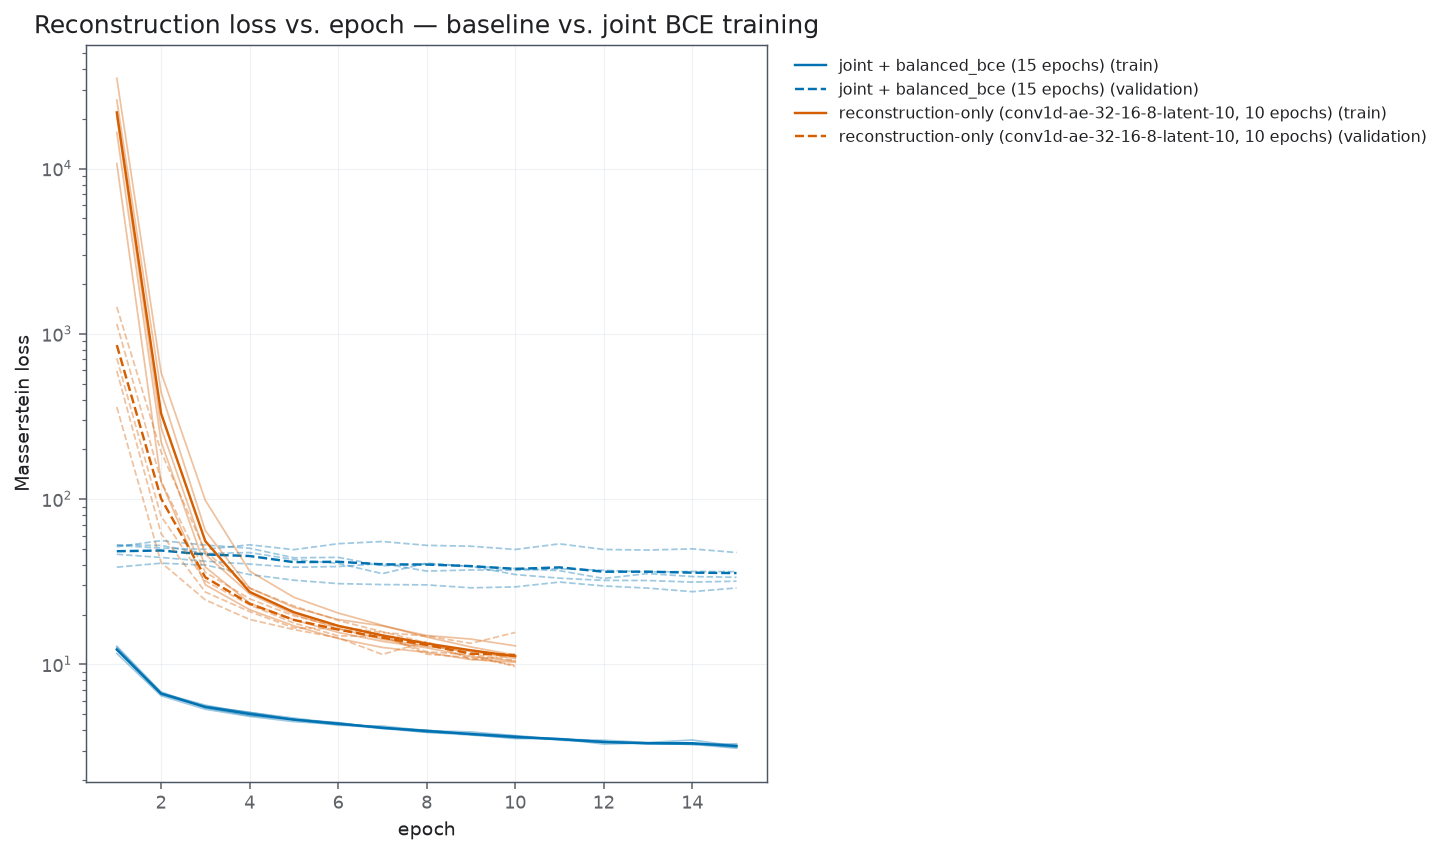

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def _mean_curve(rows: pd.DataFrame, value_key: str) -> tuple[np.ndarray, np.ndarray]:
    grouped = rows.dropna(subset=[value_key]).groupby("epoch")[value_key].mean()
    return grouped.index.to_numpy(), grouped.to_numpy()


figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, experiment in enumerate(experiment_order):
    experiment_rows = frame[frame["experiment"] == experiment]
    color = theme.color_for_model(experiment, index)
    for value_key, linestyle, series_name in (
        ("masserstein", "solid", "train"),
        ("validation_masserstein", "dashed", "validation"),
    ):
        for _, repetition_rows in experiment_rows.groupby("repetition"):
            ordered = repetition_rows.sort_values("epoch")
            ax.plot(
                ordered["epoch"], ordered[value_key],
                color=color, linestyle=linestyle,
                linewidth=theme.reference_line_width, alpha=theme.overlapping_signal_alpha,
                label="_nolegend_",
            )
        mean_epochs, mean_values = _mean_curve(experiment_rows, value_key)
        ax.plot(
            mean_epochs, mean_values,
            color=color, linestyle=linestyle,
            linewidth=theme.reconstruction_line_width,
            label=f"{experiment} ({series_name})",
        )
ax.set_yscale("log")
ax.set(xlabel="epoch", ylabel="Masserstein loss", title="Reconstruction loss vs. epoch — baseline vs. joint BCE training")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=theme.legend_frame, fontsize=8)
figure.tight_layout()


## Global spatial reconstruction-error comparison

### Methodology
#### Theoretical
- The epoch-trajectory plot above shows *that* the two models differ in
  reconstruction error; it says nothing about *where* in the tissue the error sits.
  If error concentrates in the *same* spatial regions for both models, that points to
  a hard-to-reconstruct region of the tissue/dataset itself (background, low-signal
  areas, acquisition artifacts) rather than either model specifically; if the two
  models' high-error regions disagree, that points to model-specific weaknesses
  instead.

#### Implementation
- Same per-pixel Masserstein cost as `part_5` (`masserstein_distances`), computed for
  every train/validation/test pixel **both models actually share** — the two
  campaigns use different splits, so `map_shared_ids_by_split` (the intersection) is
  used, the same fairness fix the later per-pixel section in this notebook also uses.
  Values are mapped back onto the dataset's native `(x, y)` grid via
  `reader.MapSpectrumValuesToImage(fill_value=np.nan)`, then rendered as a grid: one
  row per model, one column per split, **one shared color scale across all six
  panels** (`visualization.spatial.plot_image_grid(..., shared_scale=True)`) so the
  maps are directly comparable. Sparse split populations (56 validation / 42 test
  shared pixels, vs. 2662 train) are made visible with `dilate_sparse_map` — a
  NaN-safe `scipy.ndimage.maximum_filter` + `binary_dilation` (radius=3) — since a
  handful of single-pixel points would otherwise be invisible at figure resolution.

### Notes
- The three campaigns' shared-pixel counts are small on validation/test (2662 train,
  56 validation, 42 test) — read the validation/test maps as a coarse, spatially
  qualitative check rather than a dense per-region breakdown.


In [7]:
import torch

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.reconstruction.metrics import masserstein_distances
from msi_autoencoder_wrapper.visualization.spatial import plot_image_grid

# Defined again here (not yet available until the later 'Visual reconstruction
# comparison' section) so this section stays self-contained at its earlier position.
BASELINE_MODEL_NAME = "kidney-architecture-binning__cfg_d1feaa5d34e5__grid_0010__rep_00"
PREDICTIVE_MODEL_NAME = "kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00"

MAP_SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
MAP_SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not MAP_SCRATCH_WORKSPACE_ROOT.is_symlink():
    MAP_SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

map_wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
map_wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

map_wrapper.load_configuration(model_name=BASELINE_MODEL_NAME)
map_baseline_partitions = map_wrapper.active_dataset.create_partitions()
map_baseline_model = map_wrapper.active_model
map_baseline_model.eval()
map_baseline_device = next(map_baseline_model.parameters()).device
map_mass_axis = map_wrapper.active_context.binner.GetXAxis()
map_reader = map_wrapper.active_context.reader

map_wrapper.load_configuration(model_name=PREDICTIVE_MODEL_NAME)
map_predictive_partitions = map_wrapper.active_dataset.create_partitions()
map_predictive_model = map_wrapper.active_model
map_predictive_model.eval()
map_predictive_device = next(map_predictive_model.parameters()).device

map_shared_ids_by_split = {
    split_name: sorted(
        set(map_baseline_partitions.manifest.assignments[split_name])
        & set(map_predictive_partitions.manifest.assignments[split_name])
    )
    for split_name in ("train", "validation", "test")
}
for split_name, ids in map_shared_ids_by_split.items():
    print(f"{split_name}: {len(ids)} pixel(s) shared by both models")


2026-08-27 02:44:54,370 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-27 02:44:54,372 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-27 02:44:54,378 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-27 02:44:54,380 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 02:44:54,396 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


...

2026-08-27 02:46:19,386 | INFO     | msi_autoencoder_wrapper.configuration.orchestrator:74 | Saved configuration restoration completed.


2026-08-27 02:46:19,388 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-27 02:46:41,468 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-27 02:46:41,691 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


train: 2662 pixel(s) shared by both models
validation: 56 pixel(s) shared by both models
test: 42 pixel(s) shared by both models


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


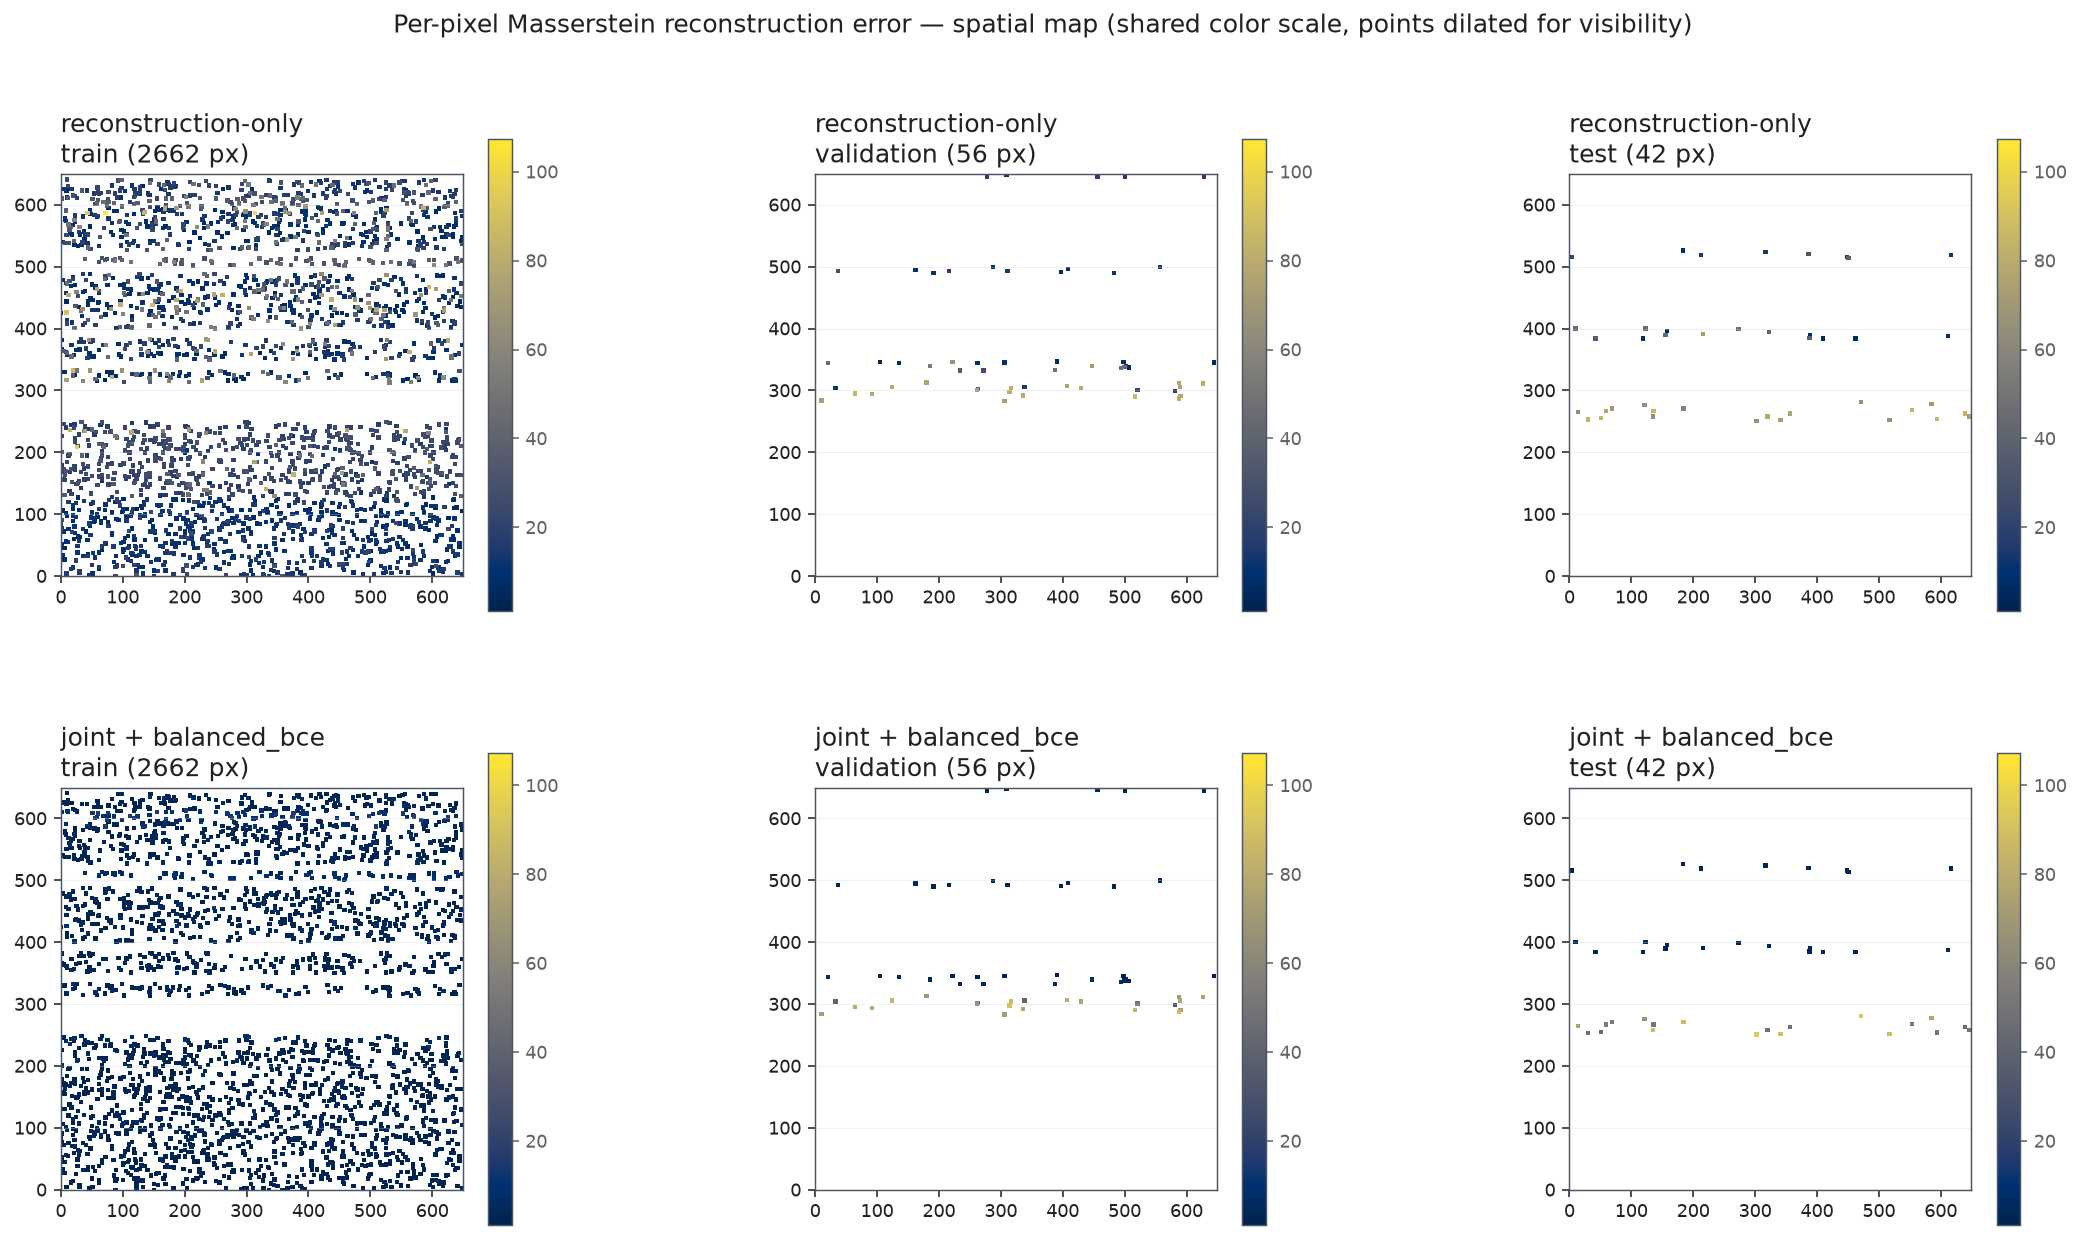

In [8]:
def per_pixel_masserstein(model, partitions, device, split_name: str, spectrum_ids: list[int], batch_size: int = 256) -> np.ndarray:
    dataset = getattr(partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    spectra = torch.stack([dataset[index][1] for index in ordered_indices]).float()
    reconstructions = []
    with torch.no_grad():
        for start in range(0, len(spectra), batch_size):
            batch = spectra[start : start + batch_size].to(device)
            reconstructions.append(model(batch)["reconstruction"].cpu().numpy())
    reconstructions = np.concatenate(reconstructions, axis=0)
    return masserstein_distances(spectra.numpy(), reconstructions, map_mass_axis, device="cpu")


MAP_TOTAL_SPECTRA = map_reader.GetNumberOfSpectra()


def full_length_error_map(model, partitions, device, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    costs = per_pixel_masserstein(model, partitions, device, split_name, spectrum_ids)
    full = np.full(MAP_TOTAL_SPECTRA, np.nan, dtype=np.float32)
    full[np.asarray(spectrum_ids, dtype=int)] = costs
    return full


MAP_SHORT_LABELS = {"baseline": "reconstruction-only", "predictive": "joint + balanced_bce"}


def dilate_sparse_map(values: np.ndarray, radius: int = 3) -> np.ndarray:
    """Grow each valid (non-NaN) point into a `(2*radius+1)`-wide block for visibility.

    The `train` split alone covers ~2662/421955 spectra (validation/test far fewer) —
    single-pixel `imshow` markers on the dataset's native ~650x650 grid are close to
    invisible. NaN-safe local-max dilation (largest error wins where two grown points
    would overlap, appropriate for an error-magnitude map); positions with no valid
    point within `radius` stay `NaN`.
    """
    from scipy import ndimage

    plane = values[0] if values.ndim == 3 else values
    valid = np.isfinite(plane)
    if not valid.any():
        return plane
    footprint = np.ones((2 * radius + 1, 2 * radius + 1))
    filled = np.where(valid, plane, -np.inf)
    dilated_values = ndimage.maximum_filter(filled, footprint=footprint)
    dilated_valid = ndimage.binary_dilation(valid, structure=footprint)
    return np.where(dilated_valid, dilated_values, np.nan)


spatial_error_images = {}
for model_key, model, partitions, device in (
    ("baseline", map_baseline_model, map_baseline_partitions, map_baseline_device),
    ("predictive", map_predictive_model, map_predictive_partitions, map_predictive_device),
):
    for split_name, ids in map_shared_ids_by_split.items():
        full = full_length_error_map(model, partitions, device, split_name, ids)
        spatial = map_reader.MapSpectrumValuesToImage(full, fill_value=np.nan)
        spatial_error_images[f"{MAP_SHORT_LABELS[model_key]}\n{split_name} ({len(ids)} px)"] = dilate_sparse_map(spatial.values)

spatial_figure, spatial_axes = plot_image_grid(spatial_error_images, columns=3, shared_scale=True, theme=theme)
for axis in spatial_axes:
    axis.title.set_fontsize(10)
spatial_figure.suptitle("Per-pixel Masserstein reconstruction error \u2014 spatial map (shared color scale, points dilated for visibility)", fontsize=13)
spatial_figure.subplots_adjust(top=0.88, wspace=0.5, hspace=0.3)


## Average Masserstein change between the two experiments

### Methodology
#### Theoretical
- A single headline number — mean validation Masserstein at each run's own
  best-checkpoint epoch — summarizing the epoch-trajectory comparison above into one
  comparable figure per experiment.

#### Implementation
- `best_validation_masserstein` per run is read at the epoch where that run's
  `best_loss` (the trainer's own running-minimum validation *total* loss) was
  recorded. For the baseline this is exactly the validation Masserstein (single
  objective, so `total_loss == masserstein`); for `grid_0000`, `total_loss` also
  includes the BCE head term, so the value reported is the validation Masserstein
  **at that same best-checkpoint epoch**, not a separately-reminimized Masserstein
  value — i.e. "what the reconstruction loss actually was at the checkpoint each run
  restored," consistent with how `final_performance_summary` reads `best_loss` in
  `part_0`/the binning campaign's own notebook. Aggregated via
  `groupby("experiment")["validation_masserstein_at_best"].agg(["mean", "std", "count"])`
  across the 5 repetitions of each experiment.

### Notes
- baseline: mean 10.83 (std 1.49, n=5); joint + balanced_bce: mean 35.14 (std 7.56,
  n=5) — a +24.30 absolute / +224% relative increase in validation Masserstein for
  the joint model at its own best checkpoint. Consistent with the overfitting shape
  seen in the epoch trajectory above, now as a single comparable number.


In [9]:
def best_checkpoint_masserstein(tasks, experiment_key: str) -> pd.DataFrame:
    rows = []
    for task in tasks:
        epoch_entries = [e for e in task.history if e.get("metrics", {}).get("epoch") is not None]
        if not epoch_entries:
            continue
        best_entry = min(
            epoch_entries,
            key=lambda entry: entry["metrics"].get("best_loss", float("inf")),
        )
        rows.append(
            {
                "experiment": EXPERIMENT_LABELS[experiment_key],
                "task_id": task.task_id,
                "repetition": task.repetition,
                "best_checkpoint_epoch": best_entry["metrics"]["epoch"],
                "validation_masserstein_at_best": best_entry["metrics"]["validation_masserstein"],
            }
        )
    return pd.DataFrame(rows)


best_frame = pd.concat(
    [
        best_checkpoint_masserstein(baseline_matched, "baseline"),
        best_checkpoint_masserstein(predictive_matched, "predictive"),
    ],
    ignore_index=True,
)
best_frame


,experiment,task_id,repetition,best_checkpoint_epoch,validation_masserstein_at_best
0,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000050,0,9,10.691730
1,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000051,1,10,9.868596
2,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000052,2,9,13.391882
3,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000053,3,10,10.522310
4,reconstruction-only (conv1d-ae-32-16-8-latent-...,task_000054,4,10,9.684984
5,joint + balanced_bce (15 epochs),task_000000,0,14,31.441209
6,joint + balanced_bce (15 epochs),task_000001,1,15,47.456019
7,joint + balanced_bce (15 epochs),task_000002,2,12,33.068923
8,joint + balanced_bce (15 epochs),task_000003,3,14,27.520899
9,joint + balanced_bce (15 epochs),task_000004,4,13,36.197025


In [10]:
summary = best_frame.groupby("experiment")["validation_masserstein_at_best"].agg(["mean", "std", "count"])
summary


,mean,std,count
experiment,,,
joint + balanced_bce (15 epochs),35.136815,7.563443,5
"reconstruction-only (conv1d-ae-32-16-8-latent-10, 10 epochs)",10.831900,1.492680,5


In [11]:
baseline_mean = summary.loc[EXPERIMENT_LABELS["baseline"], "mean"]
predictive_mean = summary.loc[EXPERIMENT_LABELS["predictive"], "mean"]
delta = predictive_mean - baseline_mean
print(f"baseline mean validation Masserstein (at best checkpoint):   {baseline_mean:.4f}")
print(f"predictive (BCE) mean validation Masserstein (at best checkpoint): {predictive_mean:.4f}")
print(f"delta (predictive - baseline): {delta:+.4f} ({100 * delta / baseline_mean:+.1f}%)")


baseline mean validation Masserstein (at best checkpoint):   10.8319
predictive (BCE) mean validation Masserstein (at best checkpoint): 35.1368
delta (predictive - baseline): +24.3049 (+224.4%)


## Per-spectrum reconstruction comparison — train/validation/test

### Methodology
#### Theoretical
- The aggregate curves and summary number above show *that* the baseline generalizes
  better; this section shows *what that looks like* on actual spectra — the same
  pixels, reconstructed by both models, across three categories: **train** (both
  models optimized directly on these), **validation** (neither model trained on
  these, but each model's checkpoint *selection* —
  `training.checkpoint.restore_best`, `../report/methodology.md` §6 — used them),
  and **test** (neither model touched these in any way, the strongest form of
  "unseen").

#### Implementation
- Restricting every category to pixels present in **both** campaigns' matching split
  (the two campaigns' train/validation/test assignments are not identical — see the
  caveats below) is what makes the two models' reconstructions of one pixel directly
  comparable. Each spectrum gets two figures via
  `visualization.spectra.plot_spectrum_comparison`: the top panel overlays the input
  spectrum with both models' reconstructions; the bottom panel is the **residual**,
  computed exactly as `input - reconstruction` (a positive spike means the model
  *under*-predicted that bin, a negative spike means it *over*-predicted). The full
  Δm/z = 200-900 range is plotted first, then a second, zoomed view over a ±15 m/z
  window centered on that spectrum's own single highest-intensity bin (same
  convention as the reconstruction campaign's own notebook) — the full-range view is
  where Masserstein-relevant broad differences are visible; the zoom is where
  individual peak shape/height differences actually resolve.

### Notes
- See the "Notes" cell after the train/validation/test plots below for what these
  figures actually show.


In [12]:
import torch

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.visualization.spectra import plot_spectrum_comparison


### Load one representative repetition of each model

Repetition 0 of each — both campaigns' repetitions share seeds pairwise (`part_0`'s
config notes), so rep 0 is as representative as any other for this qualitative check.
Loading the predictive-campaign model needs the same `/tmp` scratch-path workaround as
`part_2` (its saved `config.json` records the SLURM node's ephemeral annotation-store
path; see `part_2`'s note on this for the full explanation) — recreated here so this
notebook runs standalone.


In [13]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

BASELINE_MODEL_NAME = "kidney-architecture-binning__cfg_d1feaa5d34e5__grid_0010__rep_00"
PREDICTIVE_MODEL_NAME = "kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00"

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

wrapper.load_configuration(model_name=BASELINE_MODEL_NAME)
baseline_dataset = wrapper.active_dataset
baseline_partitions = baseline_dataset.create_partitions()
baseline_model = wrapper.active_model
baseline_model.eval()

wrapper.load_configuration(model_name=PREDICTIVE_MODEL_NAME)
predictive_dataset = wrapper.active_dataset
predictive_partitions = predictive_dataset.create_partitions()
predictive_model = wrapper.active_model
predictive_model.eval()

mass_axis = wrapper.active_context.binner.GetXAxis()
for split_name in ("train", "validation", "test"):
    print(
        f"{split_name}: baseline={len(getattr(baseline_partitions, split_name))} "
        f"predictive={len(getattr(predictive_partitions, split_name))}"
    )


2026-08-27 02:47:08,160 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-27 02:47:08,162 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-27 02:47:08,163 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-27 02:47:08,163 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 02:47:08,164 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-27 02:48:34,350 | INFO     | msi_autoencoder_wrapper.configuration.orchestrator:74 | Saved configuration restoration completed.


2026-08-27 02:48:34,352 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-27 02:48:56,529 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-27 02:48:56,715 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


train: baseline=33756 predictive=33553
validation: baseline=4219 predictive=4488
test: baseline=4220 predictive=4023


### Pick pixels both models actually agree on the status of

`assignments[split][i]` is guaranteed to match `partitions.<split>[i]`'s own returned
spectrum id (verified against this workspace directly) — so building
`{spectrum_id: local_index}` from the manifest is enough to fetch one specific shared
pixel from each dataset's split view without scanning either dataset.


In [14]:
SPLIT_LABELS = {
    "train": "trained on by both models",
    "validation": "used for checkpoint selection by both models, not trained on directly",
    "test": "held out from both models entirely",
}

shared_ids_by_split: dict[str, list[int]] = {}
index_by_split: dict[str, dict[int, int]] = {}
for split_name in SPLIT_LABELS:
    baseline_ids = set(baseline_partitions.manifest.assignments[split_name])
    predictive_ids = set(predictive_partitions.manifest.assignments[split_name])
    shared_ids_by_split[split_name] = sorted(baseline_ids & predictive_ids)
    print(f"{split_name}: {len(shared_ids_by_split[split_name])} pixel(s) shared by both models")

baseline_index_by_split = {
    split_name: {spectrum_id: index for index, spectrum_id in enumerate(baseline_partitions.manifest.assignments[split_name])}
    for split_name in SPLIT_LABELS
}
predictive_index_by_split = {
    split_name: {spectrum_id: index for index, spectrum_id in enumerate(predictive_partitions.manifest.assignments[split_name])}
    for split_name in SPLIT_LABELS
}

EXAMPLE_COUNT = 3
RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)
example_ids_by_split = {
    split_name: rng.choice(ids, size=min(EXAMPLE_COUNT, len(ids)), replace=False)
    for split_name, ids in shared_ids_by_split.items()
}


train: 2662 pixel(s) shared by both models
validation: 56 pixel(s) shared by both models
test: 42 pixel(s) shared by both models


In [15]:
ZOOM_HALF_WIDTH_MZ = 15.0


BASELINE_DEVICE = next(baseline_model.parameters()).device
PREDICTIVE_DEVICE = next(predictive_model.parameters()).device


def reconstruct(spectrum_id: int, split_name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (input, baseline_reconstruction, predictive_reconstruction) for one shared pixel."""
    baseline_item = getattr(baseline_partitions, split_name)[baseline_index_by_split[split_name][spectrum_id]]
    predictive_item = getattr(predictive_partitions, split_name)[predictive_index_by_split[split_name][spectrum_id]]
    spectrum = predictive_item[1].unsqueeze(0).float()
    with torch.no_grad():
        baseline_reconstruction = (
            baseline_model(baseline_item[1].unsqueeze(0).float().to(BASELINE_DEVICE))["reconstruction"][0]
            .cpu().numpy()
        )
        predictive_reconstruction = (
            predictive_model(spectrum.to(PREDICTIVE_DEVICE))["reconstruction"][0].cpu().numpy()
        )
    return spectrum.squeeze(0).numpy(), baseline_reconstruction, predictive_reconstruction


def plot_pixel(spectrum_id: int, split_name: str) -> None:
    """Full-range comparison, then a second figure zoomed on the input's highest peak."""
    original, baseline_reconstruction, predictive_reconstruction = reconstruct(spectrum_id, split_name)
    reconstructions = {
        EXPERIMENT_LABELS["baseline"]: baseline_reconstruction,
        EXPERIMENT_LABELS["predictive"]: predictive_reconstruction,
    }

    figure, axes = plot_spectrum_comparison(mass_axis, original, reconstructions, theme=theme)
    figure.set_size_inches(14.0, 7.5)
    axes[0].set_title(f"spectrum {spectrum_id} — {SPLIT_LABELS[split_name]} (full range)", loc="left")

    peak_index = int(np.argmax(original))
    peak_mz = float(mass_axis[peak_index])
    window_low, window_high = peak_mz - ZOOM_HALF_WIDTH_MZ, peak_mz + ZOOM_HALF_WIDTH_MZ
    window_mask = (mass_axis >= window_low) & (mass_axis <= window_high)

    zoom_figure, zoom_axes = plot_spectrum_comparison(mass_axis, original, reconstructions, theme=theme)
    zoom_figure.set_size_inches(14.0, 7.5)
    zoom_axes[0].set_xlim(window_low, window_high)
    zoom_axes[1].set_xlim(window_low, window_high)
    signal_max = max(
        original[window_mask].max(),
        baseline_reconstruction[window_mask].max(),
        predictive_reconstruction[window_mask].max(),
    )
    zoom_axes[0].set_ylim(0, signal_max * 1.1)
    residual_max = max(
        np.abs(original - baseline_reconstruction)[window_mask].max(),
        np.abs(original - predictive_reconstruction)[window_mask].max(),
    )
    zoom_axes[1].set_ylim(-residual_max * 1.1, residual_max * 1.1)
    zoom_axes[0].set_title(
        f"spectrum {spectrum_id} — {SPLIT_LABELS[split_name]} (zoom, m/z {peak_mz:.1f} ± {ZOOM_HALF_WIDTH_MZ:.0f})",
        loc="left",
    )


### Training pixels


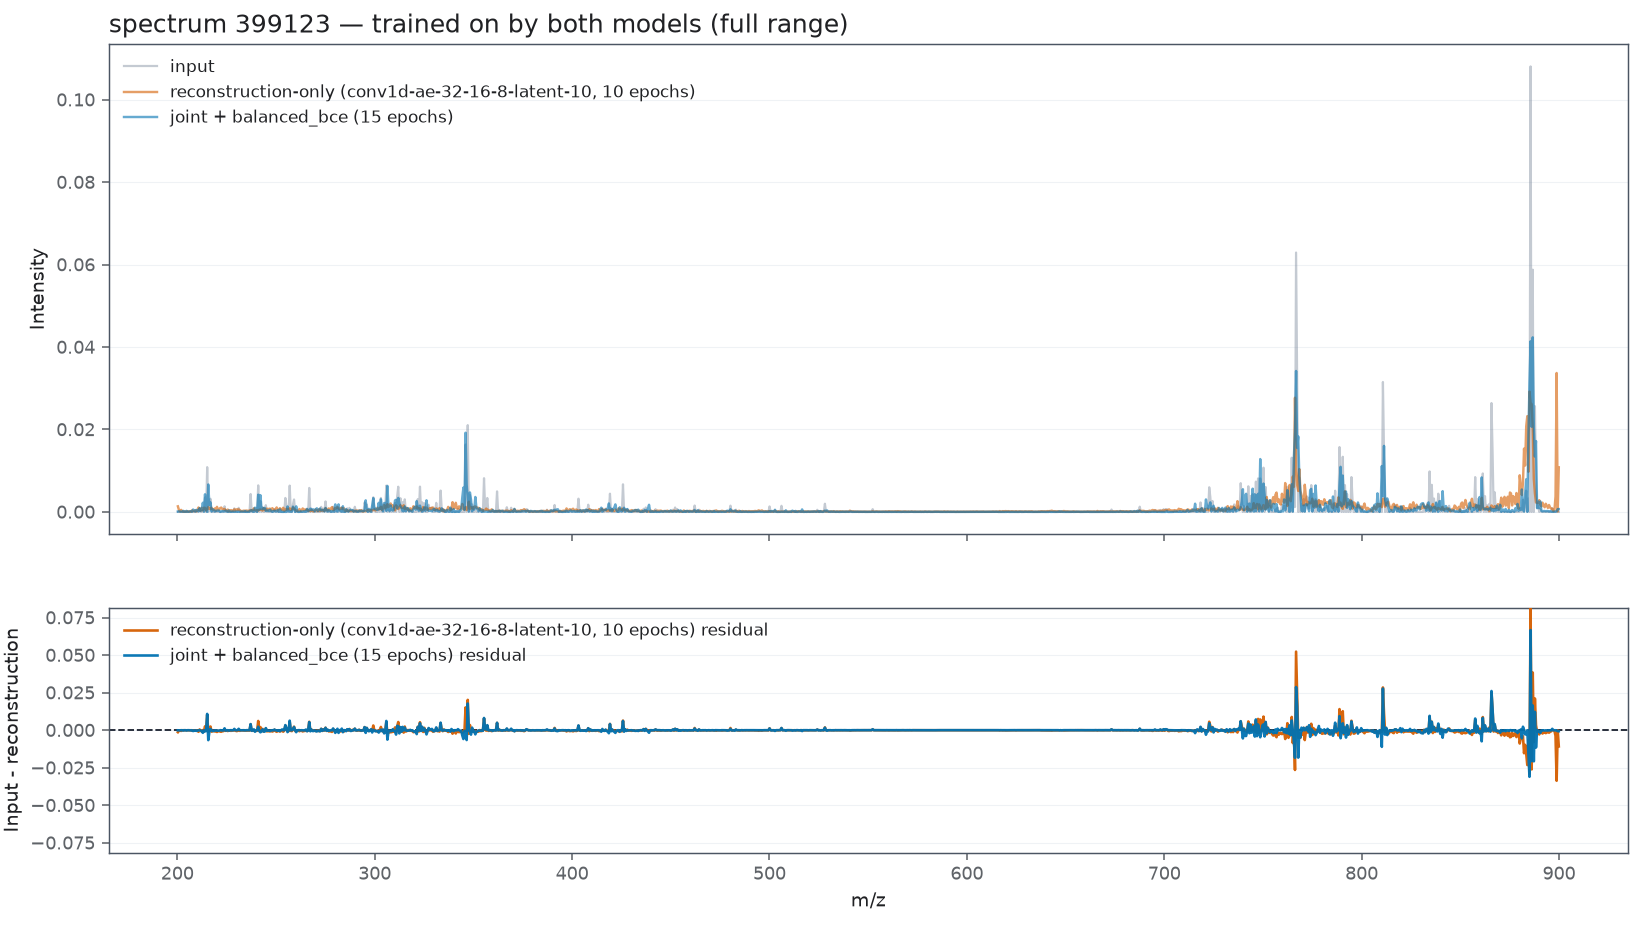

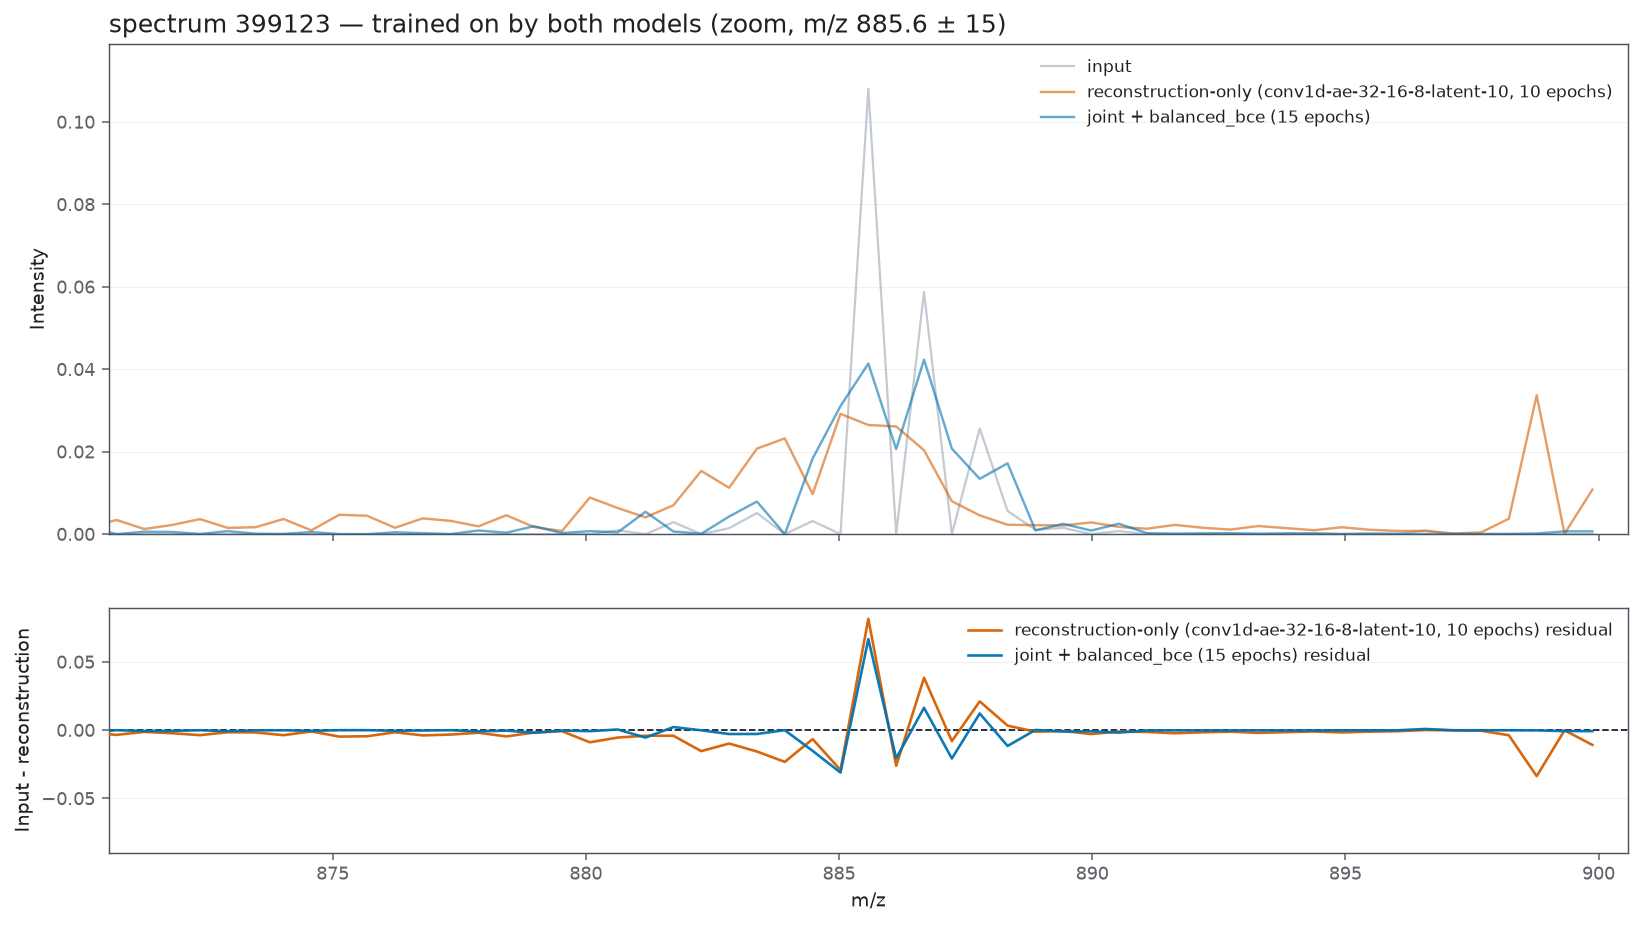

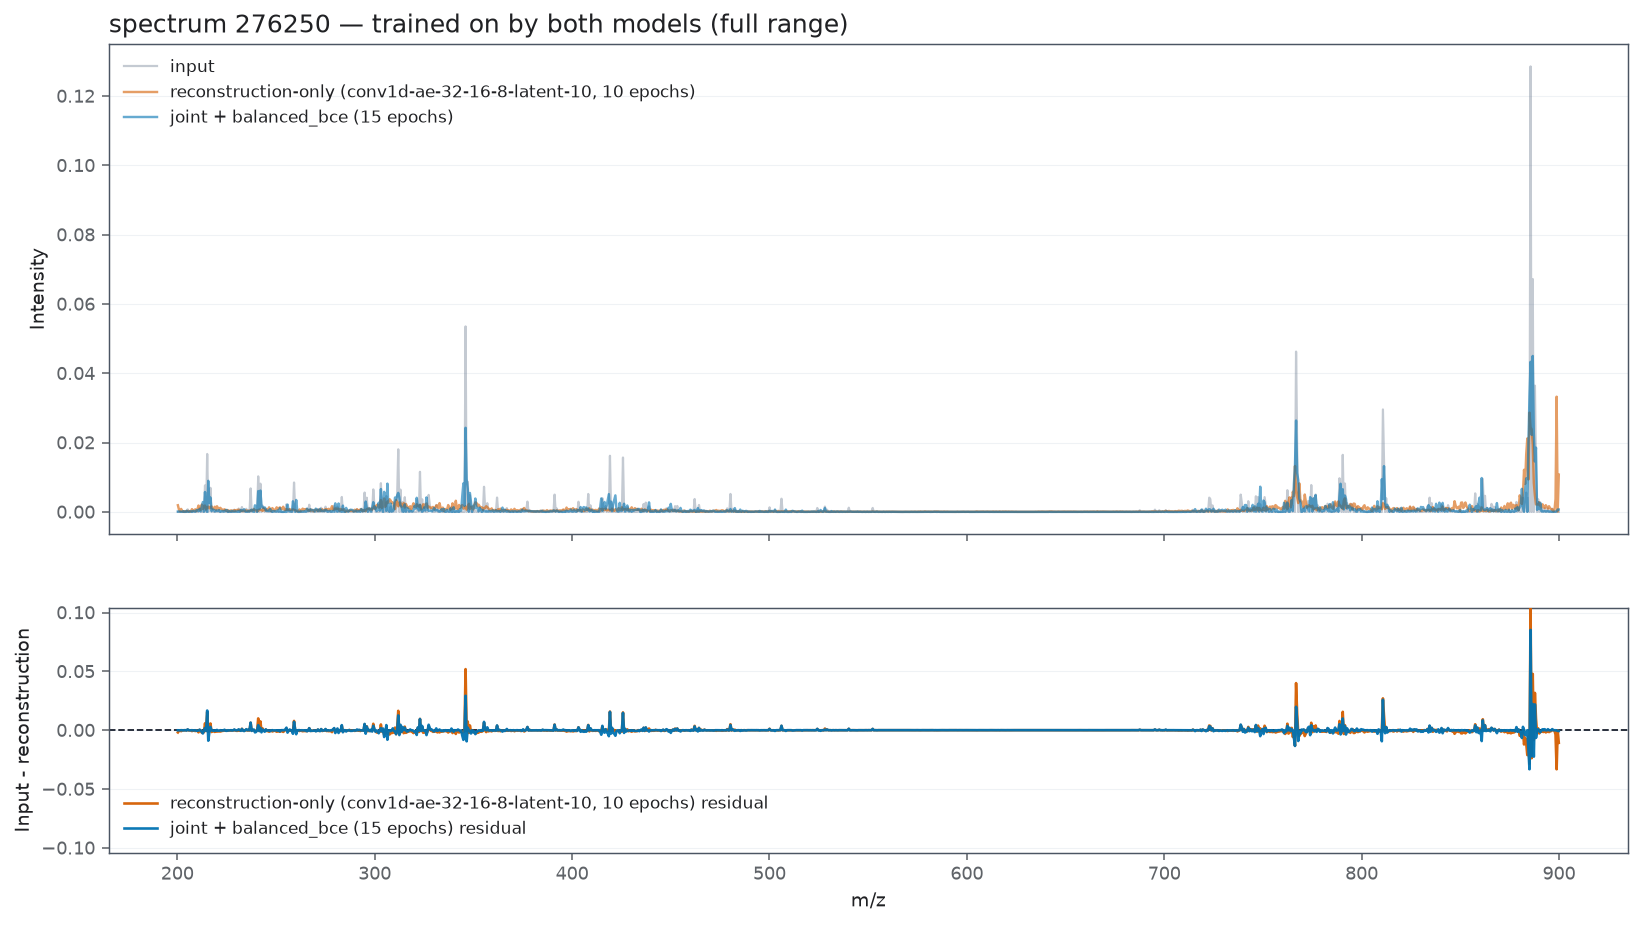

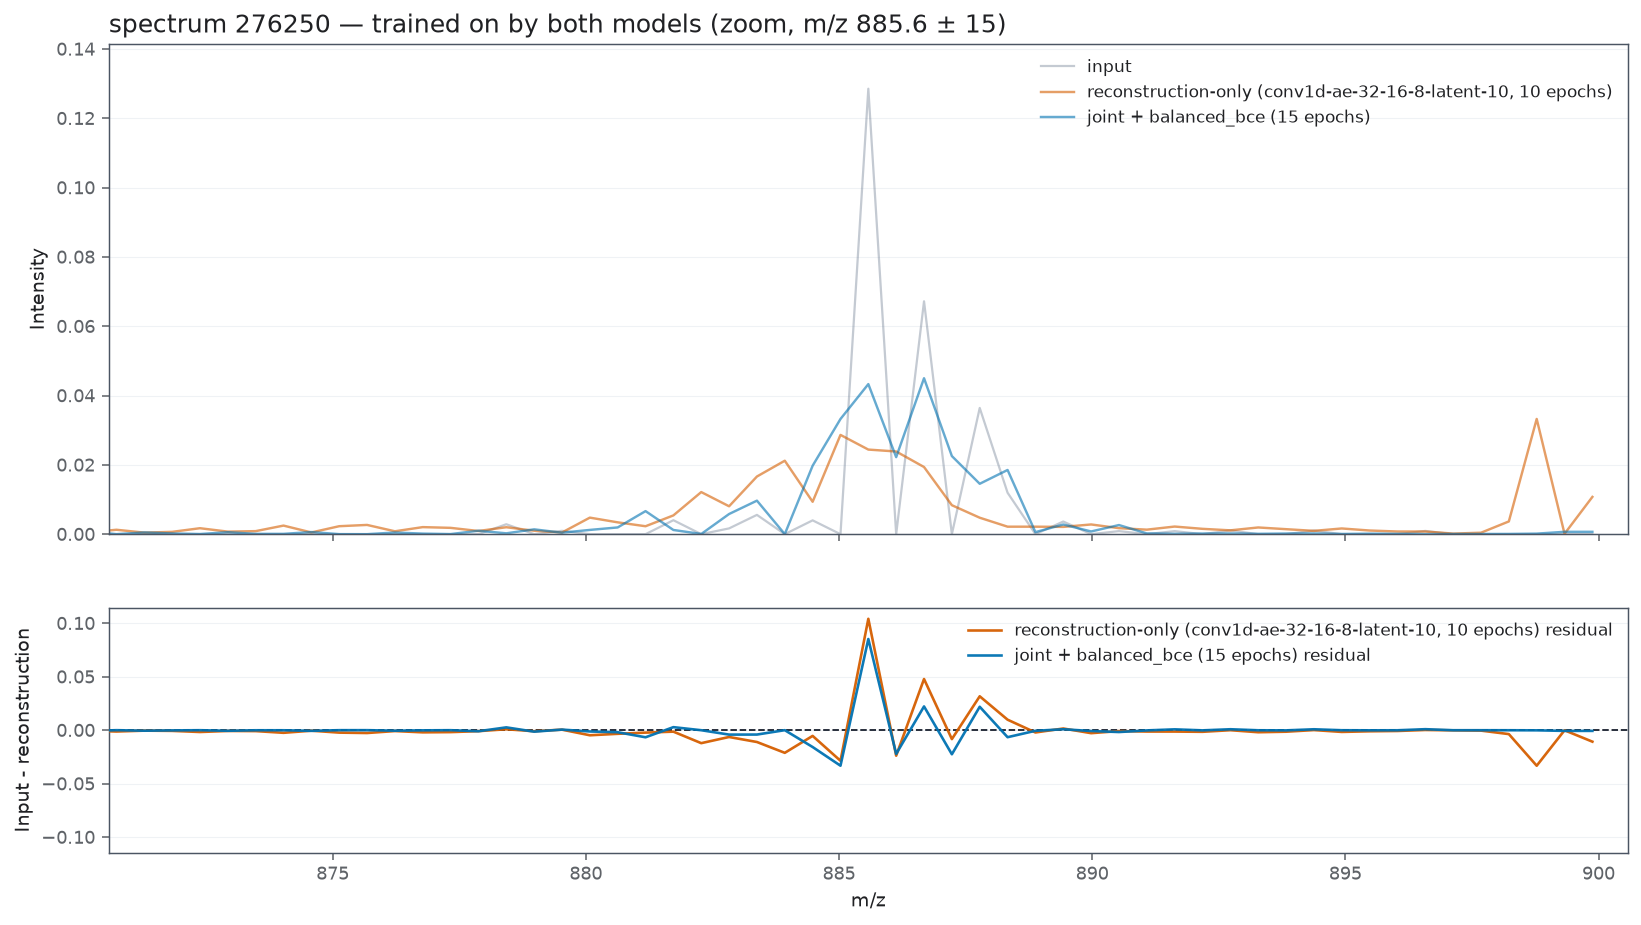

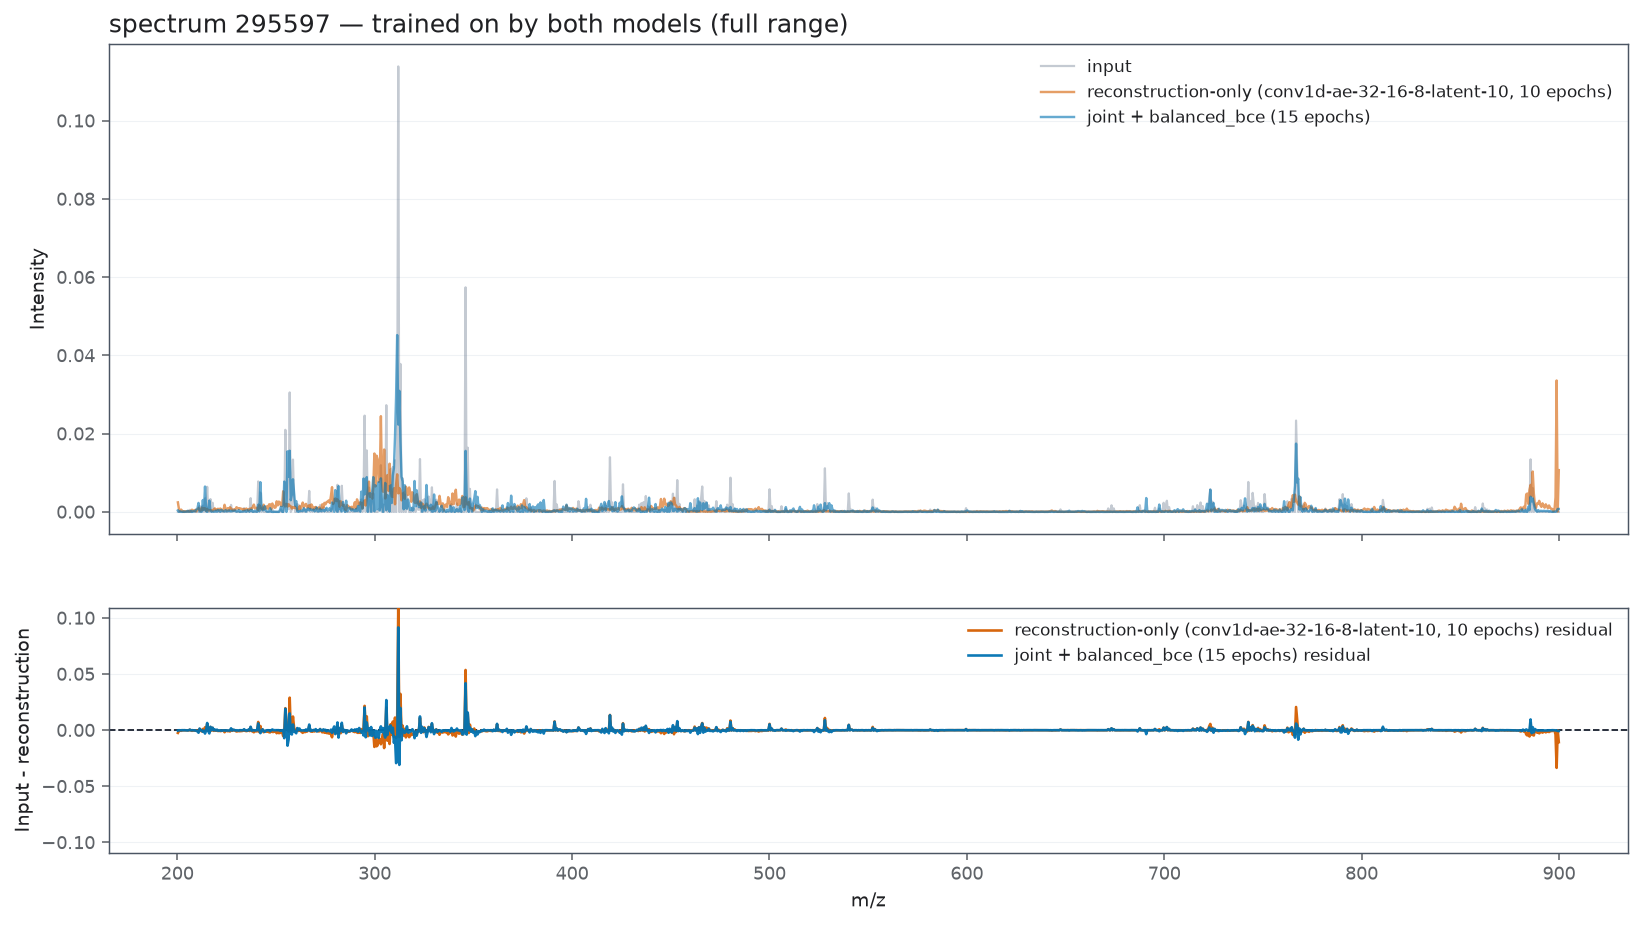

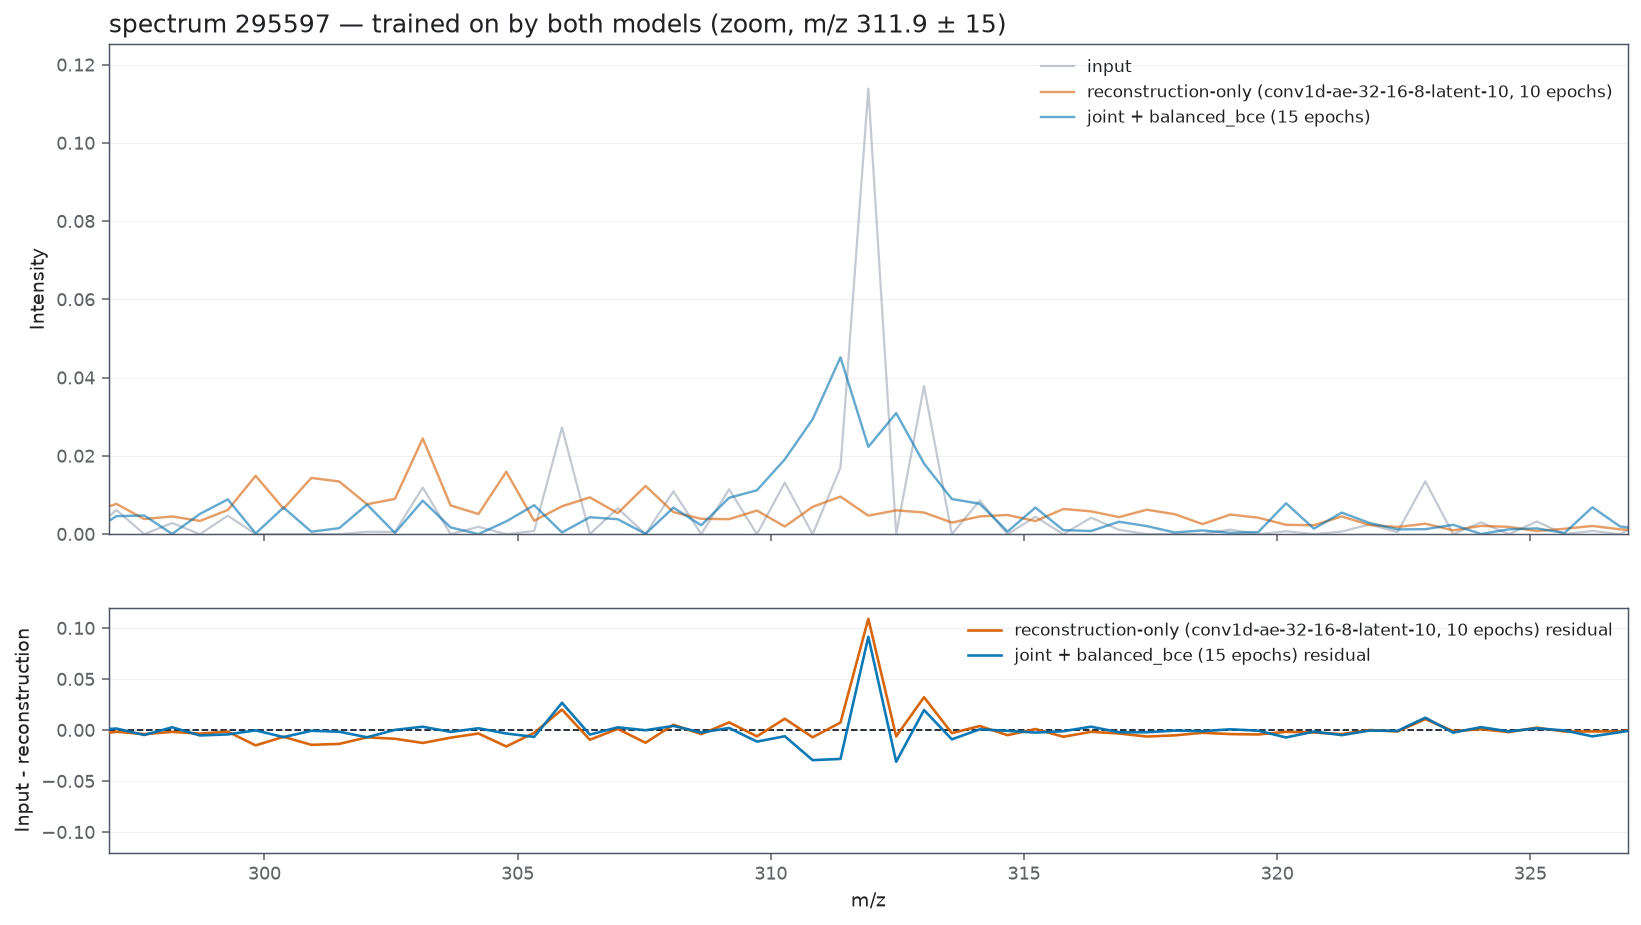

In [16]:
for spectrum_id in example_ids_by_split["train"]:
    plot_pixel(int(spectrum_id), "train")


### Validation pixels


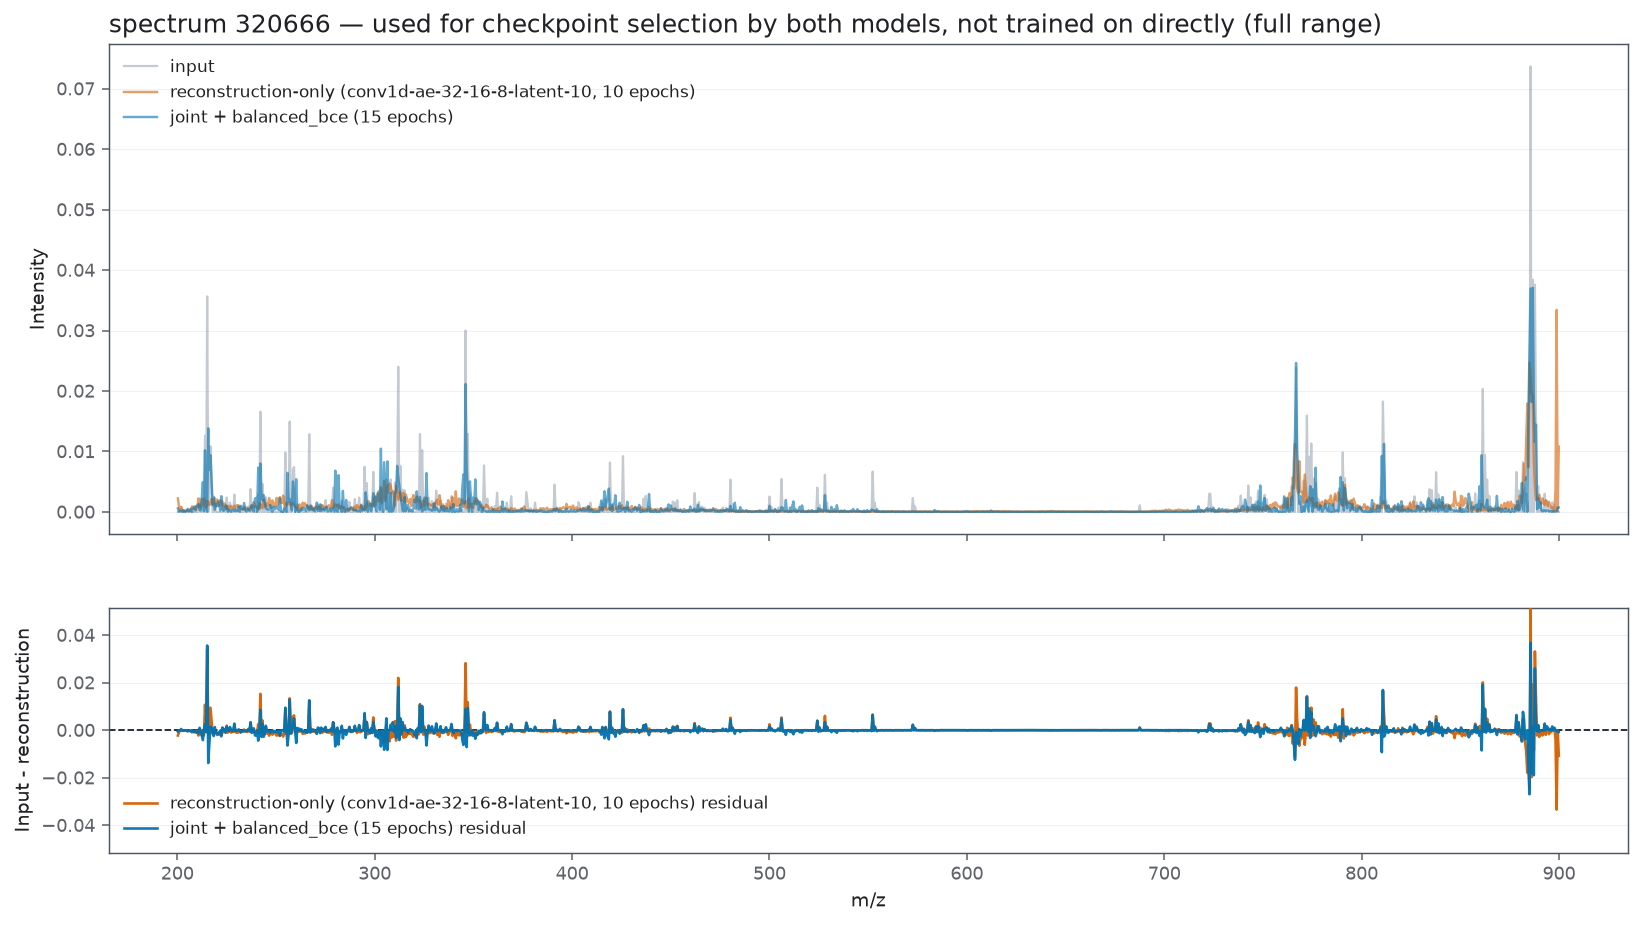

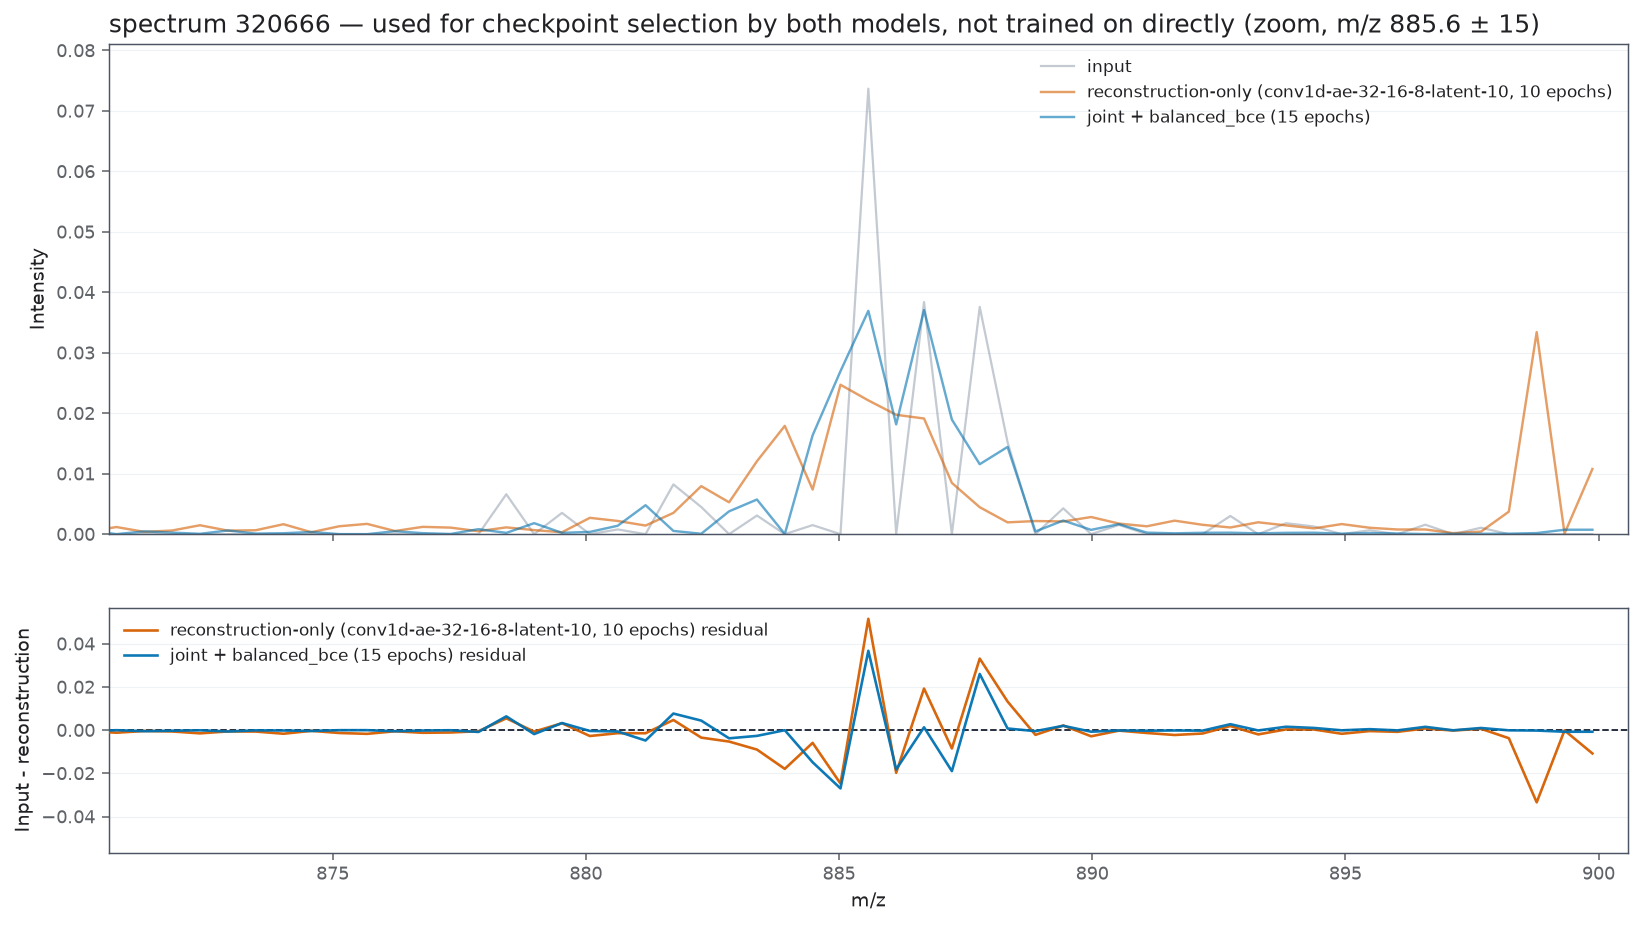

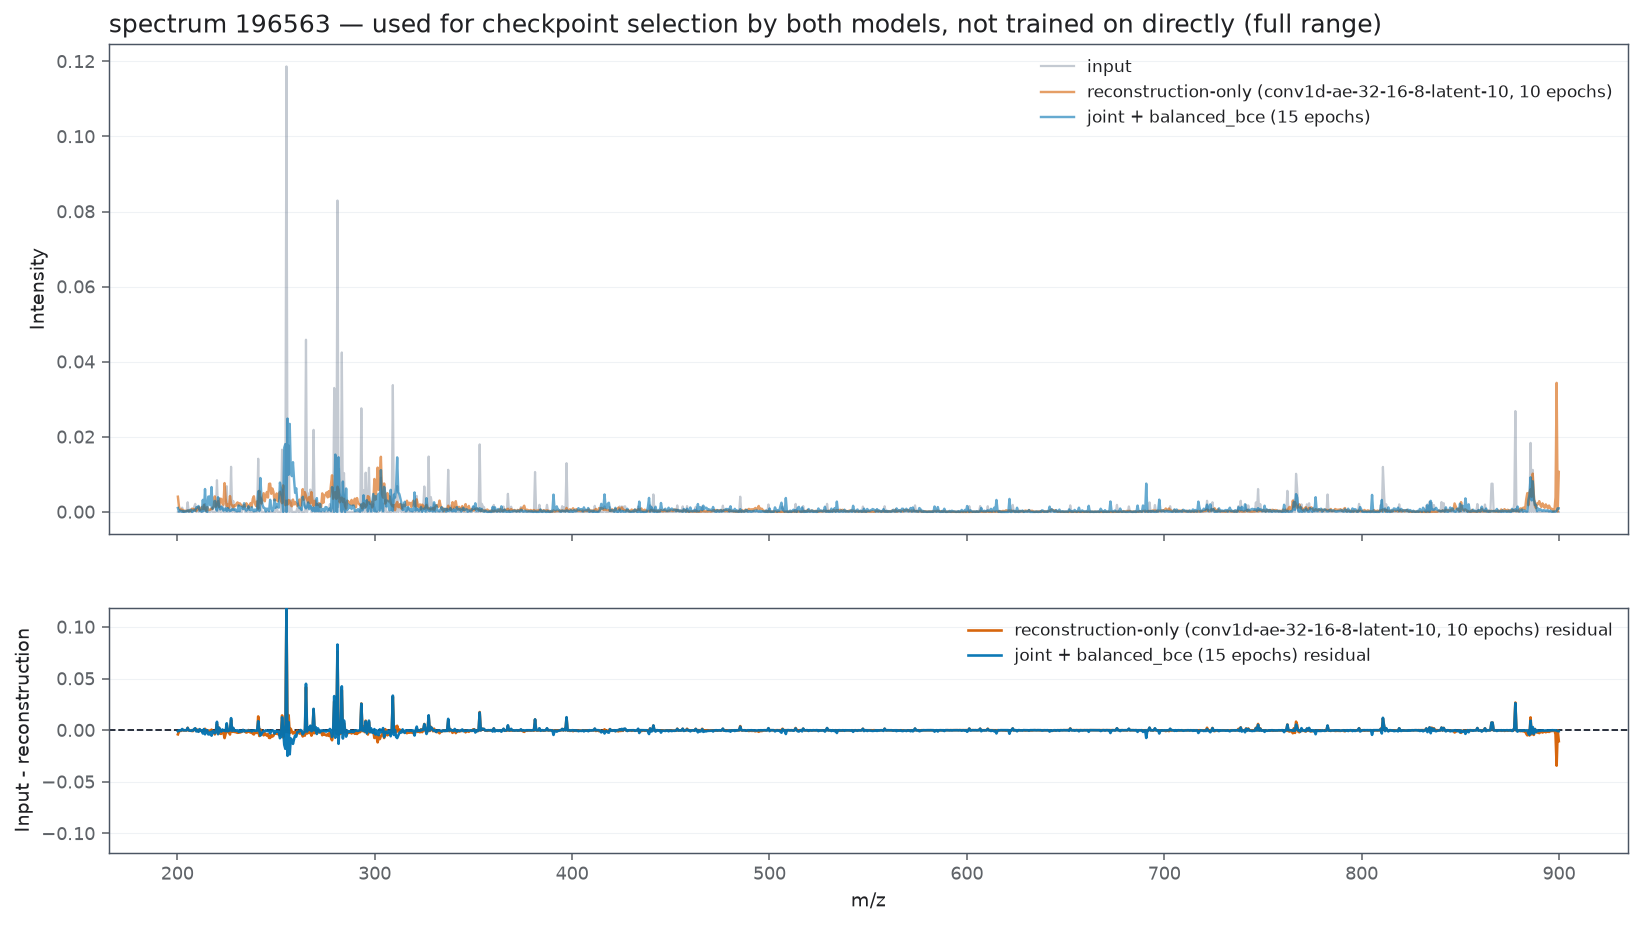

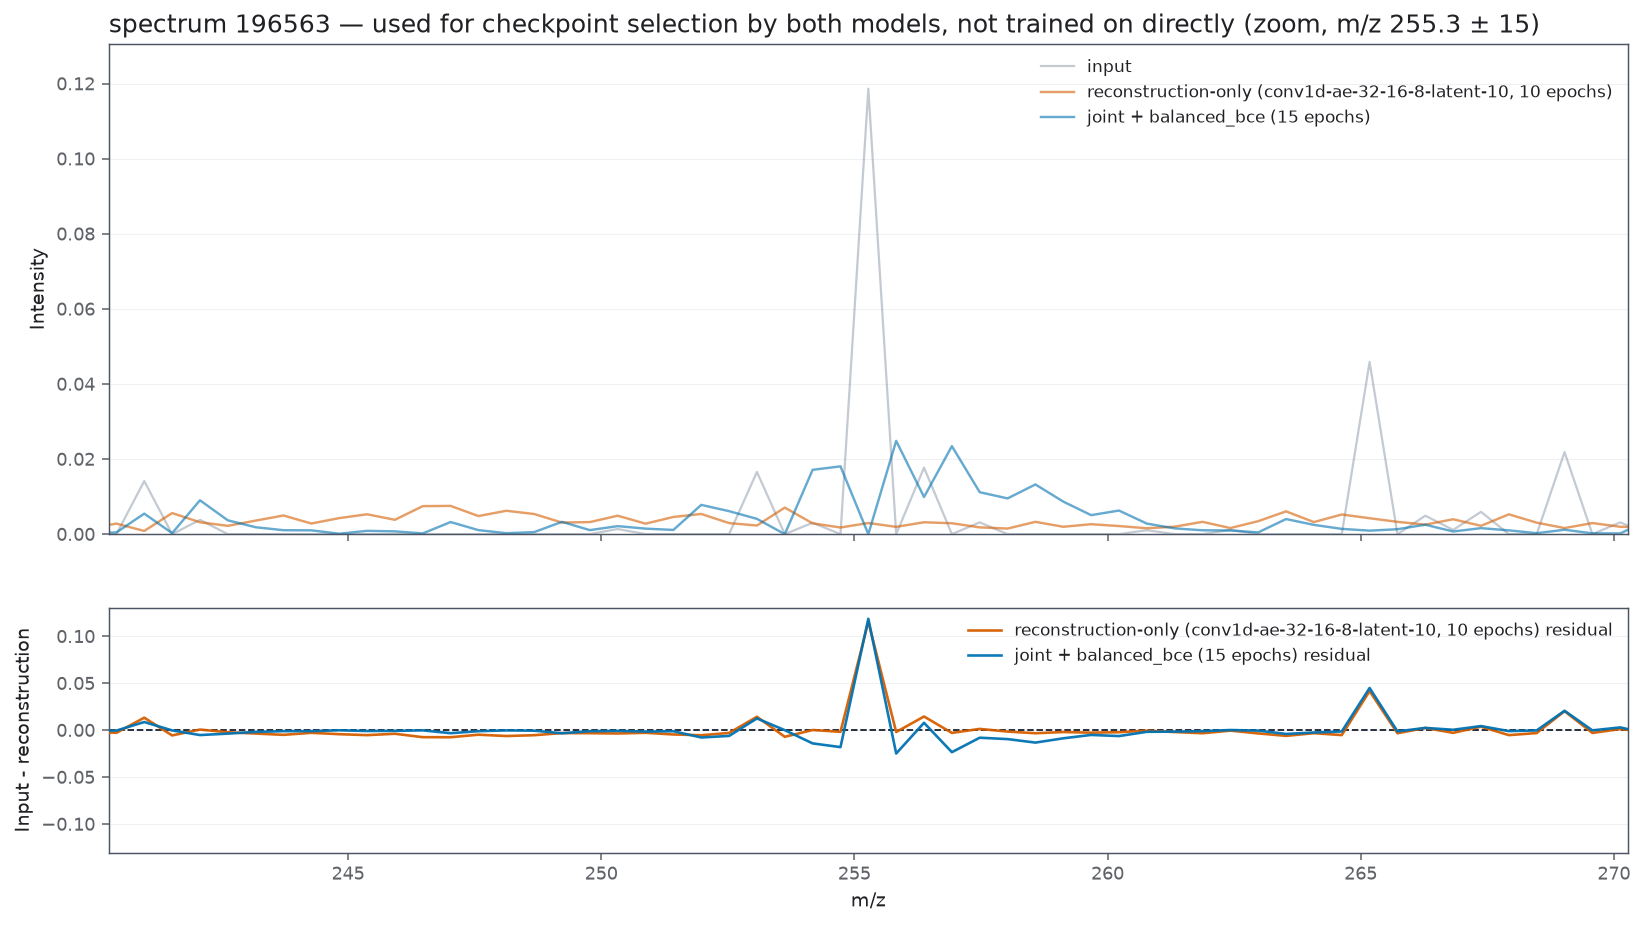

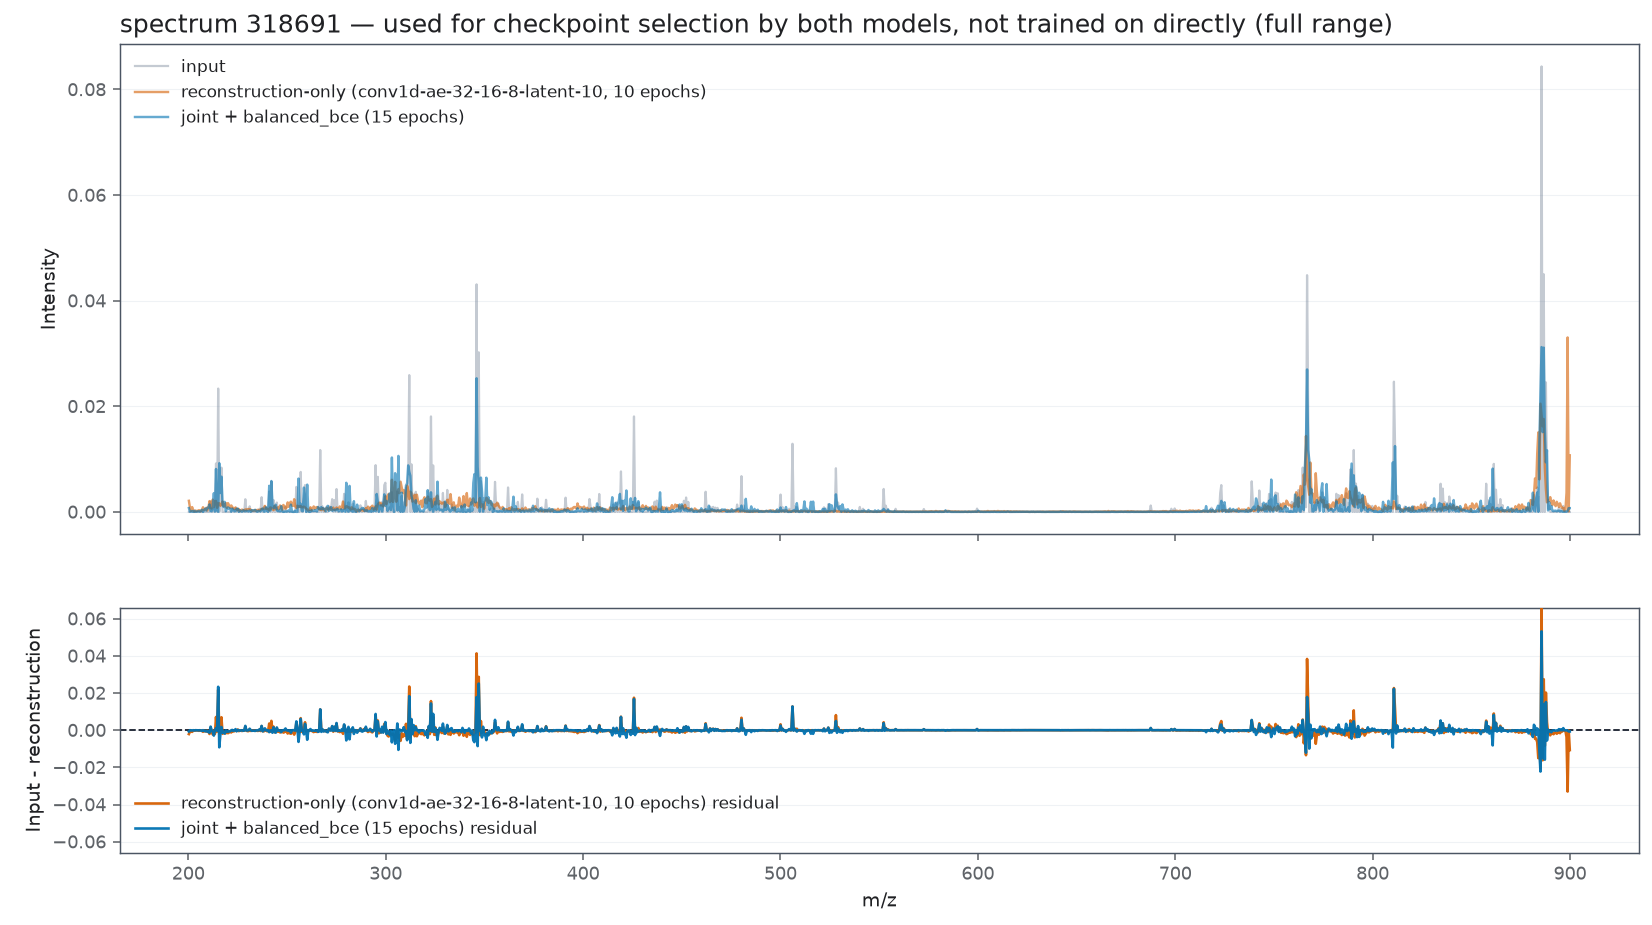

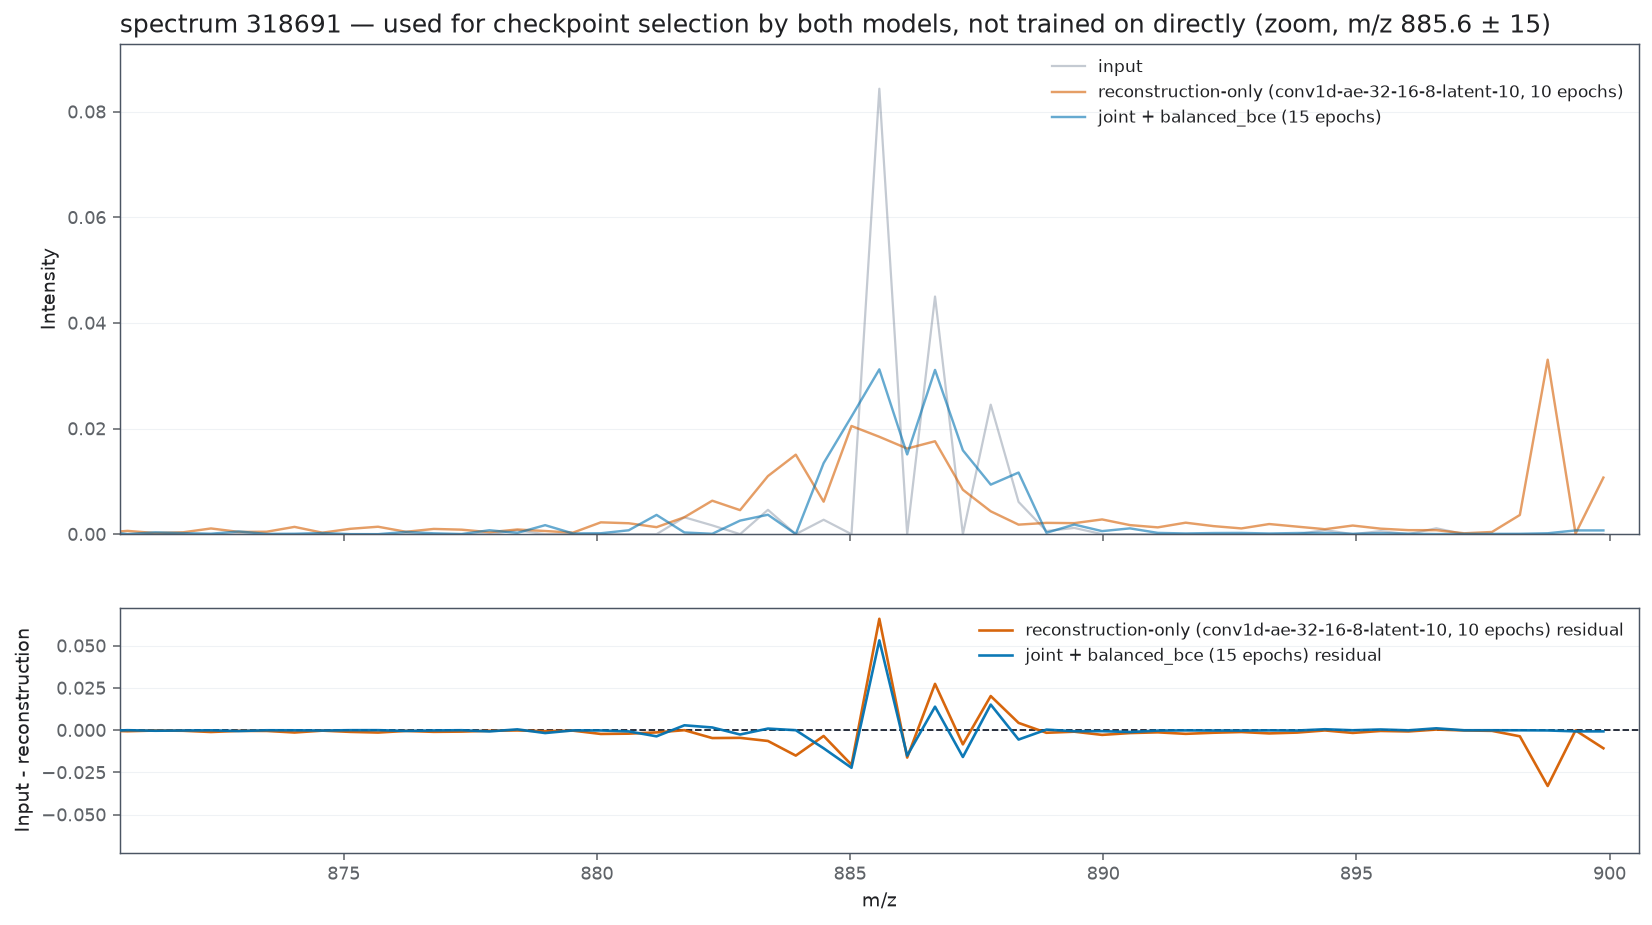

In [17]:
for spectrum_id in example_ids_by_split["validation"]:
    plot_pixel(int(spectrum_id), "validation")


### Held-out (test) pixels


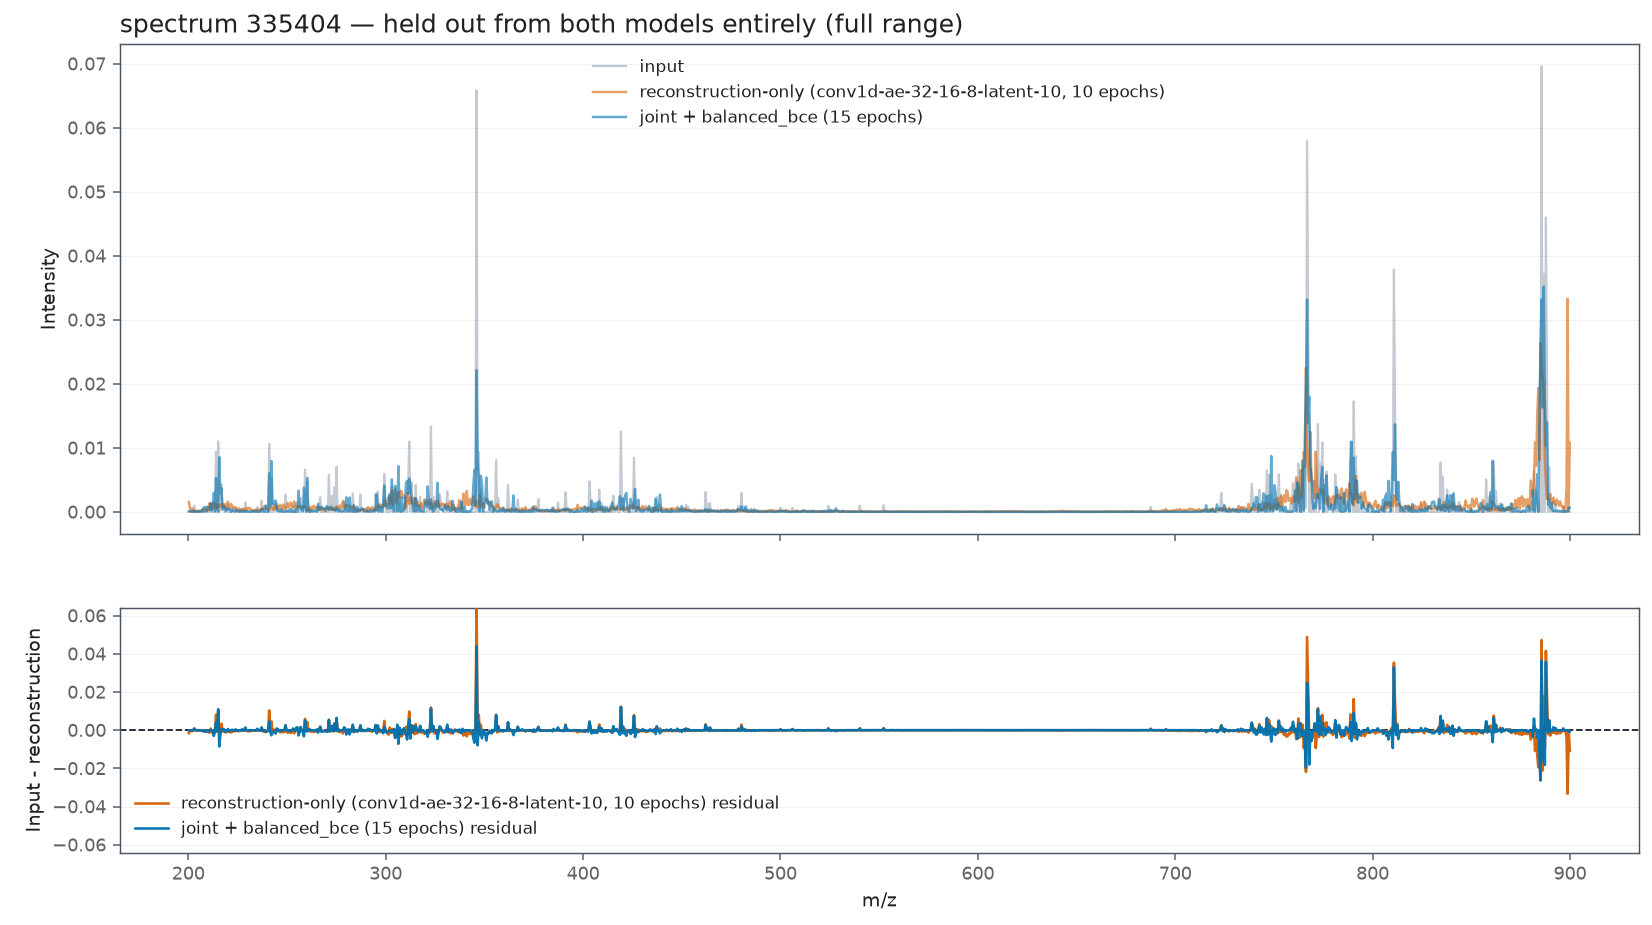

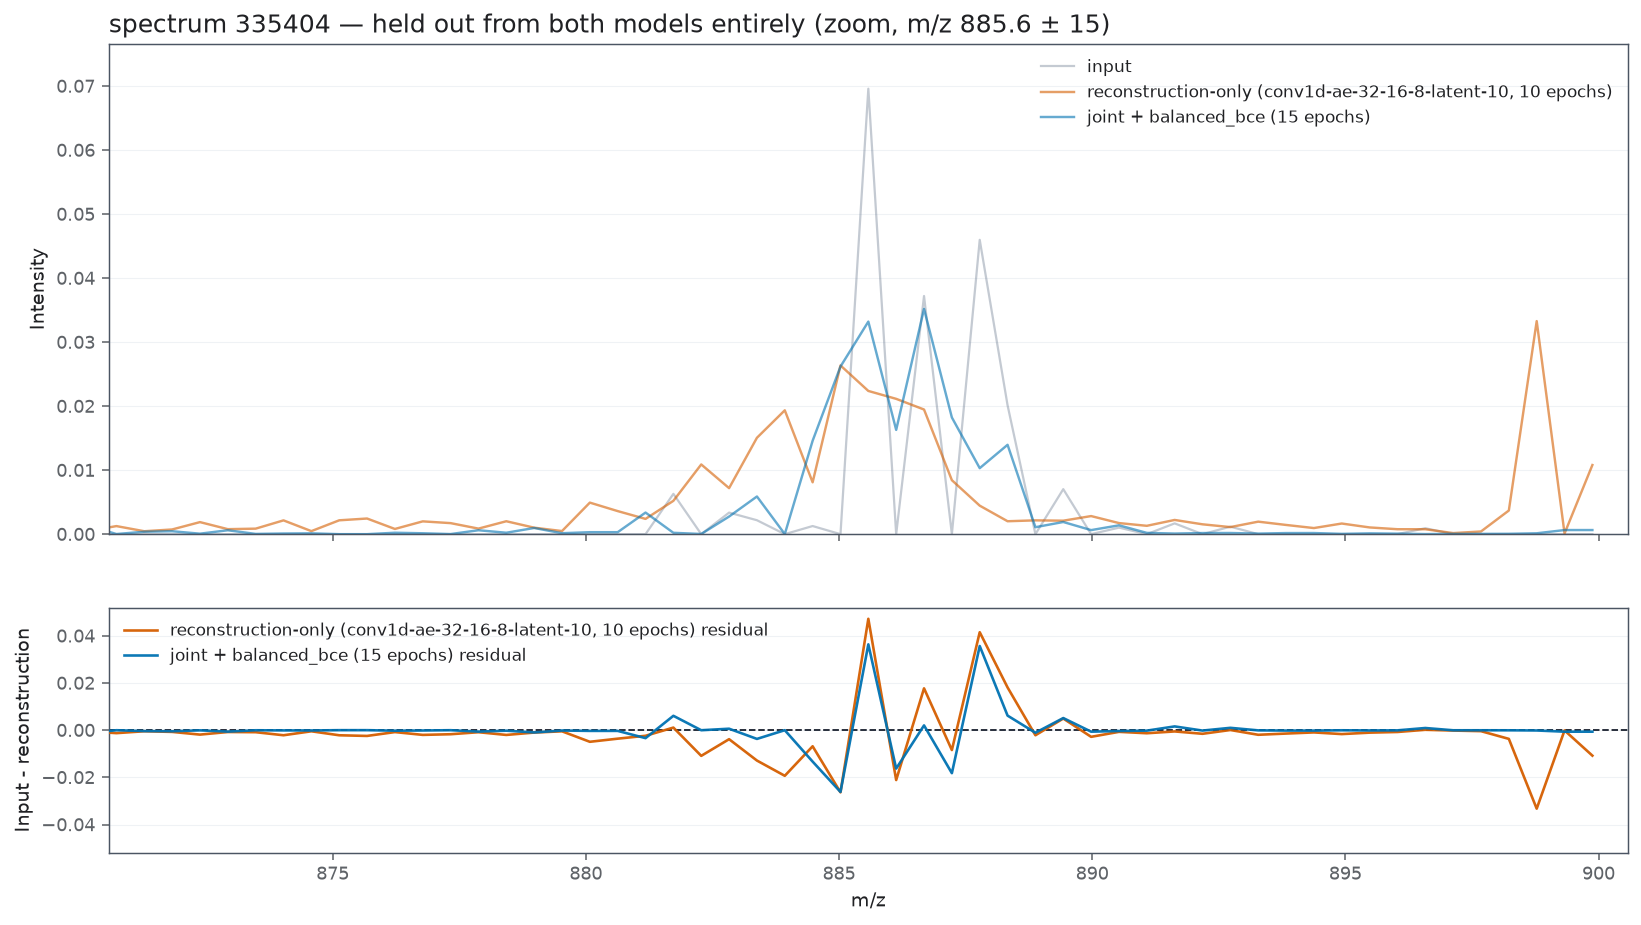

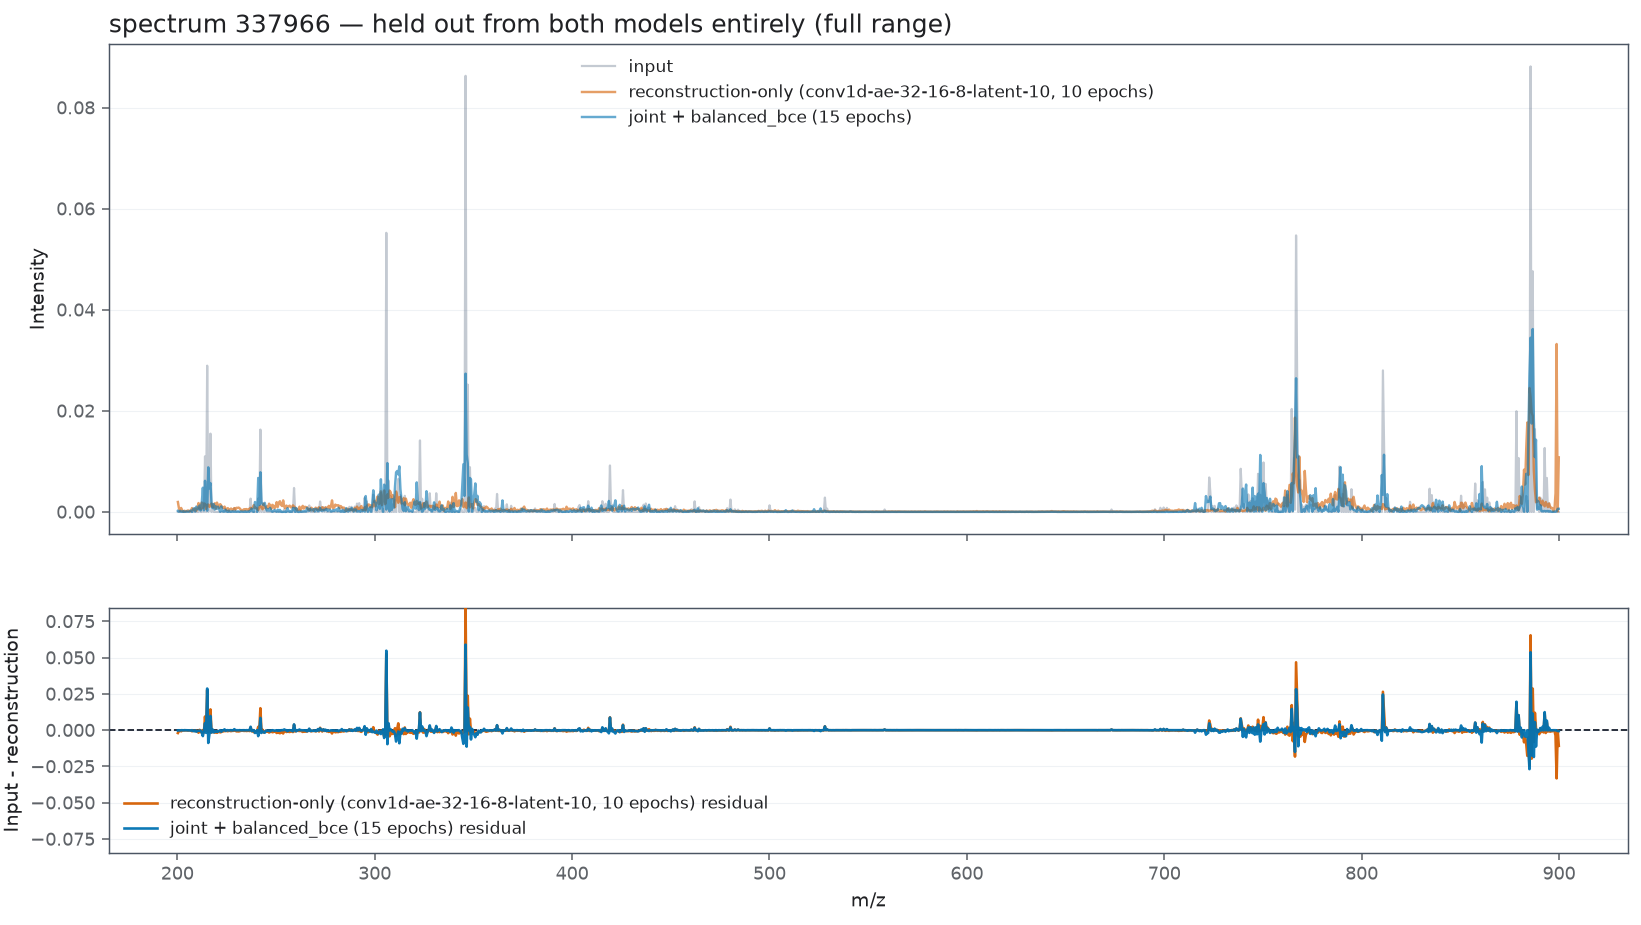

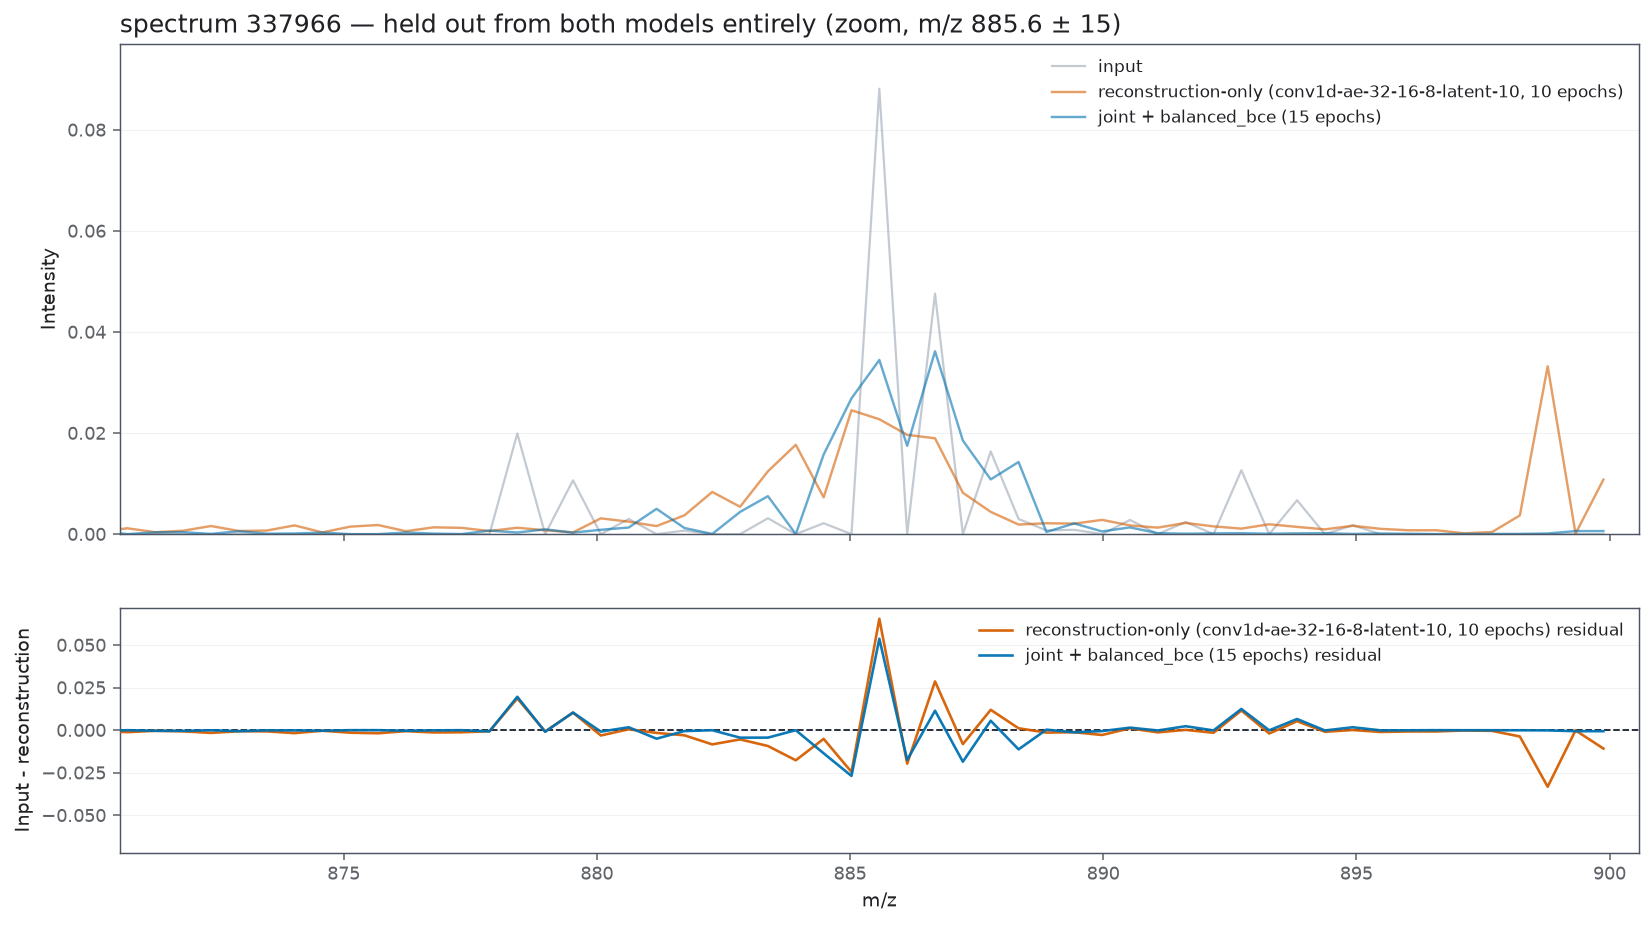

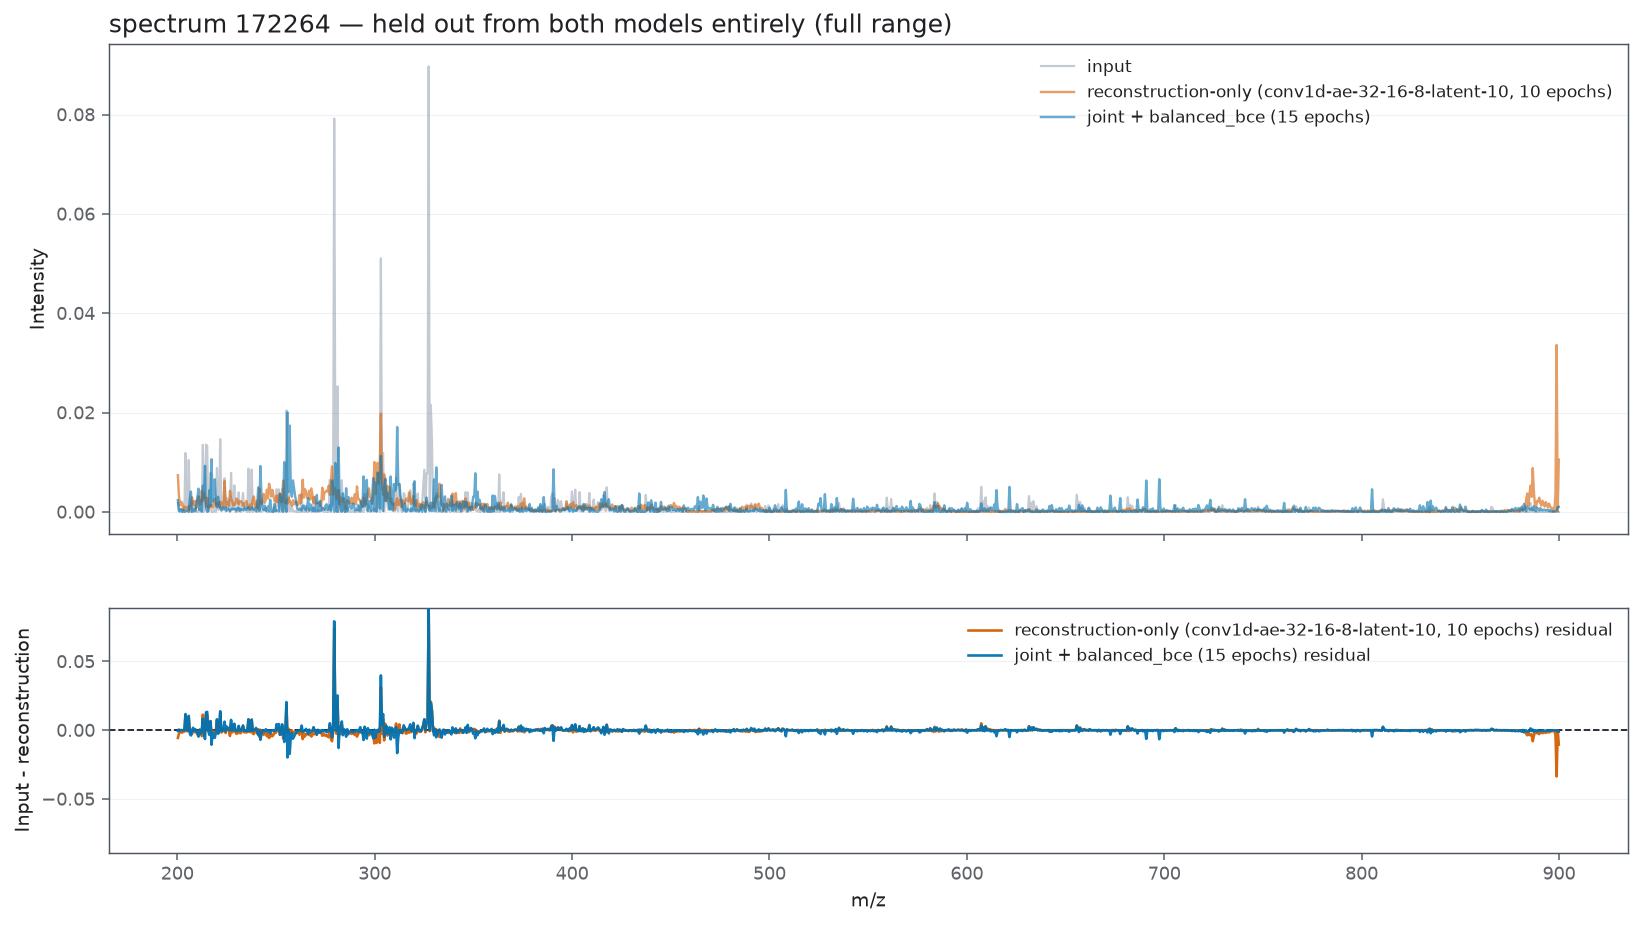

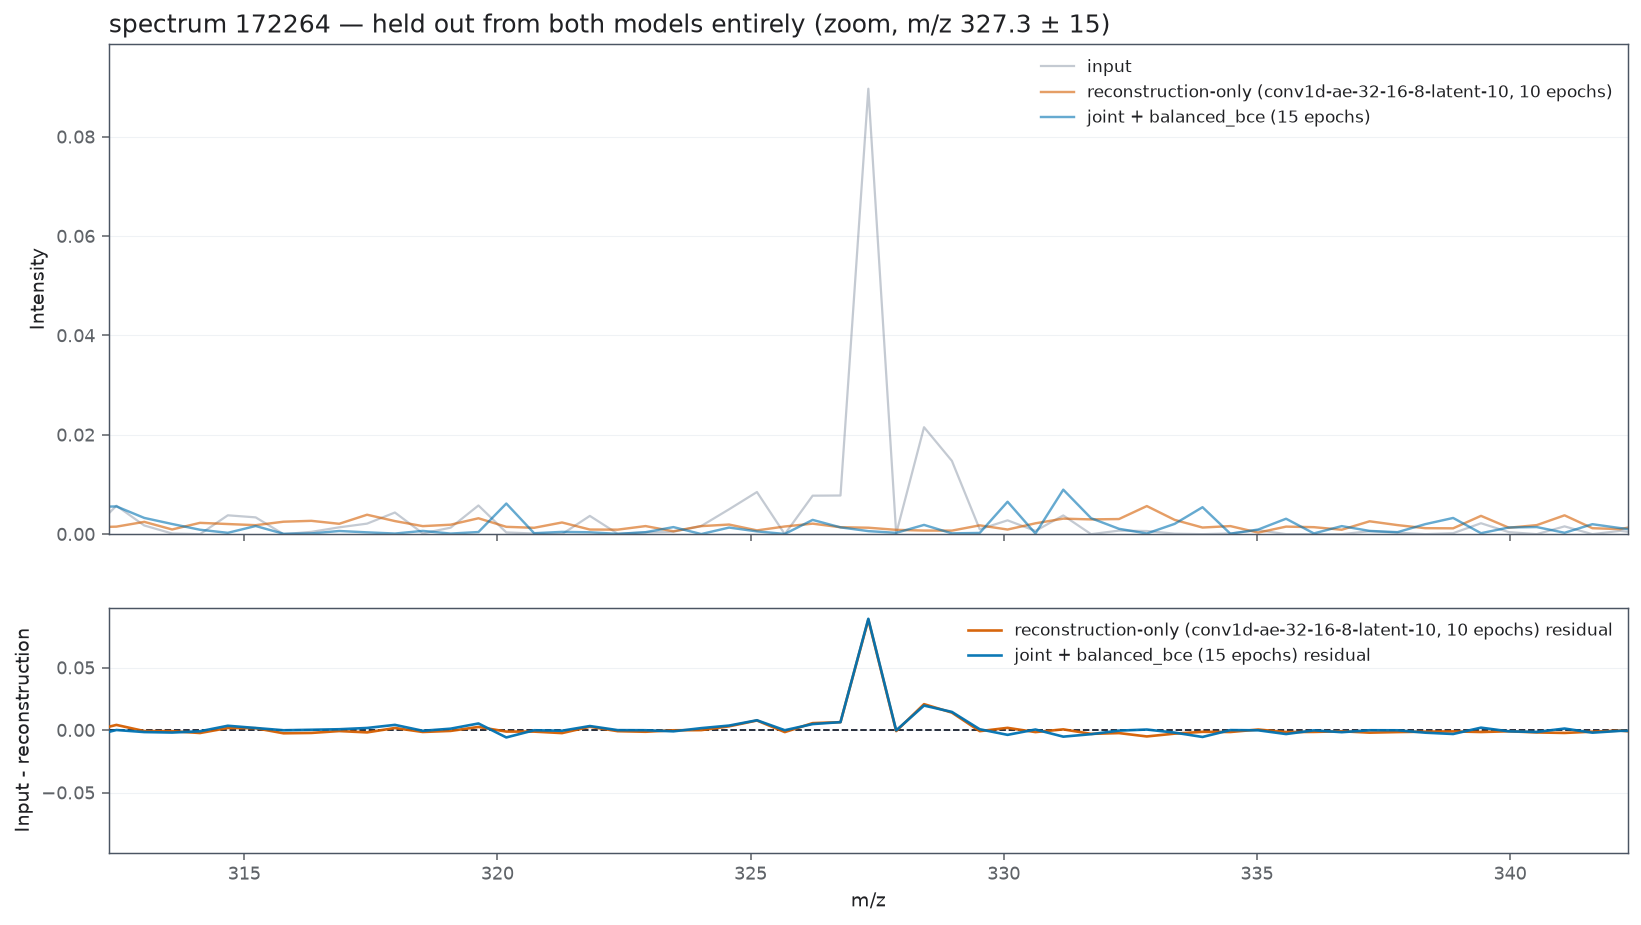

In [18]:
for spectrum_id in example_ids_by_split["test"]:
    plot_pixel(int(spectrum_id), "test")


### Notes

- **On held-out (test) and validation pixels**, the two reconstructions look broadly
  similar by eye at full range — comparable peak shapes, with the joint model showing
  somewhat larger residual spikes at a handful of peaks. The zoomed views resolve this
  further: look for the joint model's reconstruction sitting visibly further from the
  input at the zoomed peak than the baseline's, on these unseen pixels specifically.
- **On training pixels**, the difference is generally more visible: the joint model's
  reconstruction tends to track fine, noisy, sample-specific structure in the input
  more tightly than the baseline's smoother fit — the joint model fitting detail in its
  training spectra that the baseline does not reproduce, which is what "better train
  loss, worse validation loss" looks like at the spectrum level. Compare the same
  spectrum's zoomed train view against its zoomed validation/test view side by side to
  see this directly, rather than relying on the aggregate curve alone.


## Caveats — read before interpreting the numbers above

- **Different training budget.** The baseline trained reconstruction alone for 10
  epochs; `grid_0000` trained reconstruction jointly with the BCE head for 15 epochs.
  The plot above shows both full curves so this is visible directly, not hidden behind
  the single best-checkpoint number.
- **Not the same held-out pixels.** Both campaigns share the same subset/split seed
  (42) and method, but `grid_0000`'s dataset additionally excludes every spectrum with
  zero molecule annotations (`empty_spectrum_policy: exclude`, `../report/methodology.md`
  §2) — its test split (4023 spectra) is a strict subset of pixels satisfying "has ≥1
  annotation," while the baseline's test split (4220 spectra) has no such restriction.
  The two `validation_masserstein` columns above are therefore each computed on a
  population that overlaps but is not identical to the other's.
- **The visual comparison above is pixel-matched; the "average Masserstein change"
  number above it is not.** The reconstruction plots use only the 42 test / 2662 train
  pixels present in *both* campaigns' relevant split, so those specific spectra are a fair
  apples-to-apples read. The `best_checkpoint_masserstein` summary table earlier, however,
  is each model's own full validation split (4220 vs. 4023 pixels, overlapping but not
  identical) — a fresh Masserstein recomputation restricted to the 42-pixel shared test set
  would give a strictly pixel-matched version of that headline number too
  (`analysis.autoencoder.binning.model_reconstruction_analysis.model_reconstruction_records`
  computes exactly this against raw spectrum IDs); not done here since 42 pixels is a small
  sample for a summary statistic — worth doing if this number needs to support a decision.
- **Scope.** Only `grid_0000` (plain BCE) is compared here. The remaining six
  predictive ablations are a separate, later comparison (each against `grid_0000`
  itself, not against this reconstruction-only baseline) — see `../report/methodology.md`
  §5 for what they are.
